## Вітаю вас на Mid-term проєкті!

Цей проєкт призначений для того, щоб ви могли оновити та закріпити знання, які ви отримали за перші місяці навчання на курсі "Machine Learning для людей".

### Основна задача

В цьому завданні Ви - Data Scientist в барнку. Ваша задача - побудувати модель для передбачення, чи оформить клієнт в банку строковий депозит (term deposit). З подібними задачами ми стикаємось в різних компаніях і доменах, коли хочемо зрозуміти, чи клієнт купить якийсь продукт, чи буде користуватись нашим сервісом/сайтом у наступному місяці, чи придбає підписку.

Вам треба не просто побудувати модель, а і пояснити замовнику (ваш замовник тут - це ми з кураторами) як працює ця модель і чому вона дає саме такі рішення. Без цього розуміння ми не можемо перейти до впроваждення (деплойменту) моделі в продакшен.

### Практичне застовування

В реальних робочих умовах в подібних задачах у Вас дані будуть зберігатись в базі данних в динаміці (різні дії користувачів з датою і часом). Тут дані вже загреговані по клієнтам і часто саме з цього ви будете починати побудову моделі передбачення, адже це відносно просто і зручно: загрегувати дані по клієнтам до певного часу і передбачати в майбутнє (тільки в випадку тренування моделі ML наше "майбутнє" теж фактично в минулому - бо ми хочемо мати мітки в даних, а от вже при використанні моделі в продакшені і бойових умовах ви справді будете робити передбачення в майбутнє). Тож, розвʼязуємо задачку!

### Датасет і ML задача

Для виконання завдання ми використаємо набір даних, який оригінально походить з сайту [UCI Machine Learning Repository], але там неточний опис даних і багато різних піднаборів, тому ми братимемо з Kaggle dataset: https://www.kaggle.com/datasets/sahistapatel96/bankadditionalfullcsv.

Ці дані стосуються прямих маркетингових кампаній (телефонних дзвінків) португальської банківської установи. Кінцева мета класифікації - передбачити, чи підпише клієнт строковий депозит (змінна y).

Ми будемо працювати з файлом `bank-additional-full.csv`, скачати набір даних треба з Kaggle. Або можна скачати цей самий набір з гугл диска [тут](https://drive.google.com/file/d/1pDr0hAOnu1JsEiJeBu_F2Jv0GPxKiujW/view?usp=drive_link)

### Опис змінних

Цей опис є і на Kaggle, але ми переклали для вашої зручності і аби він був у вас перед очима під час роботи над проєктом.

#### **Дані про клієнта банку**:
1. **age** – вік клієнта (числова змінна).  
2. **job** – вид зайнятості (категоріальна змінна: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`).  
3. **marital** – сімейний стан (категоріальна змінна: `divorced`, `married`, `single`, `unknown`; примітка: `divorced` означає розлучений або вдівець/вдова).  
4. **education** – рівень освіти (категоріальна змінна: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`).  
5. **default** – чи є у клієнта прострочений кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
6. **housing** – чи має клієнт іпотечний кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  
7. **loan** – чи має клієнт споживчий кредит? (категоріальна змінна: `no`, `yes`, `unknown`).  

#### **Дані про останній контакт у межах поточної маркетингової кампанії**:
8. **contact** – тип зв’язку при останньому контакті (категоріальна змінна: `cellular`, `telephone`).  
9. **month** – місяць останнього контакту (категоріальна змінна: `jan`, `feb`, `mar`, …, `nov`, `dec`).  
10. **day_of_week** – день тижня останнього контакту (категоріальна змінна: `mon`, `tue`, `wed`, `thu`, `fri`).  
11. **duration** – тривалість останнього контакту в секундах (числова змінна).  
   ⚠ **Важлива примітка**: ця змінна має суттєвий вплив на цільову змінну (наприклад, якщо duration = 0, то y = `no`). Однак значення duration невідоме до здійснення дзвінка. Крім того, після завершення дзвінка значення y вже відоме. Тому цю змінну варто використовувати лише для порівняння моделей, але не включати у фінальну передбачувальну модель.  

#### **Інші атрибути**:
12. **campaign** – кількість контактів у межах поточної кампанії для цього клієнта (числова змінна, включає останній контакт).  
13. **pdays** – кількість днів, що минули з моменту останнього контакту клієнта у попередній кампанії (числова змінна; значення 999 означає, що клієнт раніше не контактувався).  
14. **previous** – кількість контактів, здійснених до цієї кампанії для цього клієнта (числова змінна).  
15. **poutcome** – результат попередньої маркетингової кампанії (категоріальна змінна: `failure`, `nonexistent`, `success`).  

#### **Атрибути соціально-економічного контексту**:
16. **emp.var.rate** – темп зміни зайнятості (щоквартальний показник, числова змінна).  
17. **cons.price.idx** – індекс споживчих цін (щомісячний показник, числова змінна).  
18. **cons.conf.idx** – індекс довіри споживачів (щомісячний показник, числова змінна).  
19. **euribor3m** – ставка Euribor на 3 місяці (щоденний показник, числова змінна).  
20. **nr.employed** – кількість працевлаштованих осіб (щоквартальний показник, числова змінна).  

#### **Цільова змінна**:
21. **y** – чи підписав клієнт строковий депозит? (бінарна змінна: `yes`, `no`).

### Ваше завдання на цей проєкт

Необхідно побудувати рішення цієї задачі бінарної класифікації. Для цього

1. Провести Exploratory Data Analysis і висунути гіпотези щодо впливу окремих ознак на цільову ознаку `y`.

2. Описати, які методи ви вважаєте доречним використовувати і обрати метрику оцінки якості моделей (метрику треба обґрунтувати).

3. Провести препроцесинг даних для подальшої їх передачі в модель. Препроцесинг має включати
  - обробку категоріальних змінних (якщо цього потребує модель)
  - групування категорій в категоріальних змінних, якщо потрібно
  - заповнення пропущених значень, якщо такі є
  - виявлення outliers і прийняття рішень, що з ними робити
  - створення додаткових ознак, які на ваш погляд поліпшать якість моделей ML.

4. Натренувати 4 різні типи моделей машинного навчання, з яких обовʼязково
  - Logistic Regression
  - kNN
  - Decision Tree
  - Принаймні один з алгоритмів бустингу

5. Створити таблицю з порівнянням якості моделей (в Google Spreadsheets або прямо в Jupyter Notebook), де зазначити
  - назву моделі
  - гіперпараметри
  - метрика якості моделі на тренувальному наборі
  - метрика якості моделі на валідаційному наборі даних
  - коментар до моделі - хороша вона, чи ні, чи варто її використовувати чи ні, чи є у вас подальші ідеї щодо експериментів з цією моделлю?

6. Для алгоритму бустингу виконати процедуру тюнингу гіперпараметрів двома способами
  - Sklearn: Randomized Search
  - Hyperopt: Bayesian Optimization.
  Виявити оптимальні гіперпараметри і зробити висновки про якість моделі в кожному з випадків.

7. Вивести важливість ознак для моделі, які показала себе найкраще і описати, чи вважаєте ви саме такий пріоритет важливості ознак адекватним з точки зору common sense?

8. Для найкращої провести аналіз впливу ознак на передбачення з допомогою бібліотеки SHAP.

9. Провести аналіз записів, в яких модель помиляється і на основі нього зазначити, яким чином можна поліпшити наявне рішення аби уникати наявних помилок?


### Результат виконання проєкту

Результатом виконання цього завдання є окремий github репозиторій з охайно оформленим Jupyter Notebook, частина коду може бути винесена в .py файли. Репозиторій має містити опис задачі, опис що було зроблено і які моделі використано, таблицю результатів експериментів (можна скріншотом або створити таблицю в Markdown форматі - див. Приклад) і висновки, що Ви досягли і що можна було б ще зробити для поліпшення результатів.


### Приклад проєкту

Для натхнення ви можете ознайомитись з проєктом, побудованим на основі цих даних за [цим посиланням](https://github.com/surtantheta/Bank_Marketing_Dataset_Machine_Learning_Project).




![](https://blogconcept2competence.wordpress.com/wp-content/uploads/2014/03/yoda.jpg)

# Result
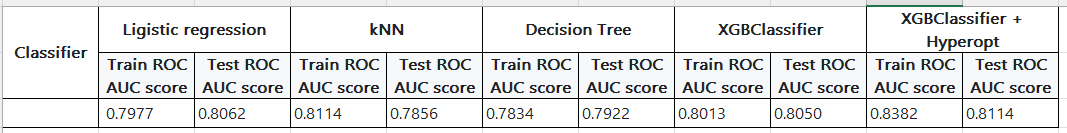

# The Task

У цьому проєкті розглядається задача бінарної класифікації клієнтів банку. Мета моделі - передбачити, чи оформить клієнт строковий депозит (y = yes) після проведення маркетингової кампанії.

Датасет містить інформацію про характеристики клієнта, результати попередніх маркетингових кампаній, параметри поточного контакту та соціально-економічні показники. Загалом набір даних містить 41 188 записів та 21 змінну.

Основна проблема задачі - дисбаланс класів, оскільки клієнтів, які не оформили депозит, значно більше, ніж клієнтів, які його оформили.

Метою проєкту є не лише побудова моделі, а й аналіз її якості, інтерпретація результатів та визначення причин помилкових передбачень.

# Approach

Для вирішення задачі було протестовано декілька алгоритмів машинного навчання:

Logistic Regression;
k-Nearest Neighbors;
Decision Tree;
XGBoost як алгоритм бустингу.

Для оцінки моделей використовувалися ROC-AUC, F1 та Accuracy. Основною метрикою було обрано ROC-AUC, оскільки задача характеризується дисбалансом класів, а Accuracy у такому випадку може бути недостатньо інформативною.

Для роботи з категоріальними змінними було використано One-Hot Encoding, а числові ознаки було масштабовано, для моделей, які цього потребують. Також досліджувалися різні методи боротьби з дисбалансом класів.

Окремо було виконано tuning XGBoost двома способами:

RandomizedSearchCV;
Bayesian Optimization за допомогою Hyperopt.

Основною метою було добитися найбільшого значення ROC-AUC з високим True positive для позитивних класів.

In [353]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImPipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc, f1_score, roc_auc_score
from sklearn.compose import ColumnTransformer
import joblib
import operator
from sklearn.preprocessing import PolynomialFeatures
from imblearn.under_sampling import RandomUnderSampler, TomekLinks
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import ADASYN
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import xgboost as xgb
from scipy.stats import randint,uniform
import warnings
import 

In [2]:
pd.set_option('display.max_columns',None)
pd.set_option('float_format', '{:.2f}'.format)
pd.set_option('display.max_rows', 100)

In [3]:
raw_df = pd.read_csv('bank-additional-full.csv',sep=';')

In [4]:
raw_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [5]:
raw_df.info(verbose = True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
raw_df.shape

(41188, 21)

In [7]:
raw_df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [8]:
raw_df.select_dtypes(include = "object").columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='object')

In [9]:
# Перевірка кількості категоріальних змінних
len(raw_df.select_dtypes(include = "object").columns)

11

In [10]:
number_df = raw_df.select_dtypes(include="number")
number_df

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,261,1,999,0,1.10,93.99,-36.40,4.86,5191.00
1,57,149,1,999,0,1.10,93.99,-36.40,4.86,5191.00
2,37,226,1,999,0,1.10,93.99,-36.40,4.86,5191.00
3,40,151,1,999,0,1.10,93.99,-36.40,4.86,5191.00
4,56,307,1,999,0,1.10,93.99,-36.40,4.86,5191.00
...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1.10,94.77,-50.80,1.03,4963.60
41184,46,383,1,999,0,-1.10,94.77,-50.80,1.03,4963.60
41185,56,189,2,999,0,-1.10,94.77,-50.80,1.03,4963.60
41186,44,442,1,999,0,-1.10,94.77,-50.80,1.03,4963.60


### Аналіз стовпця `job`

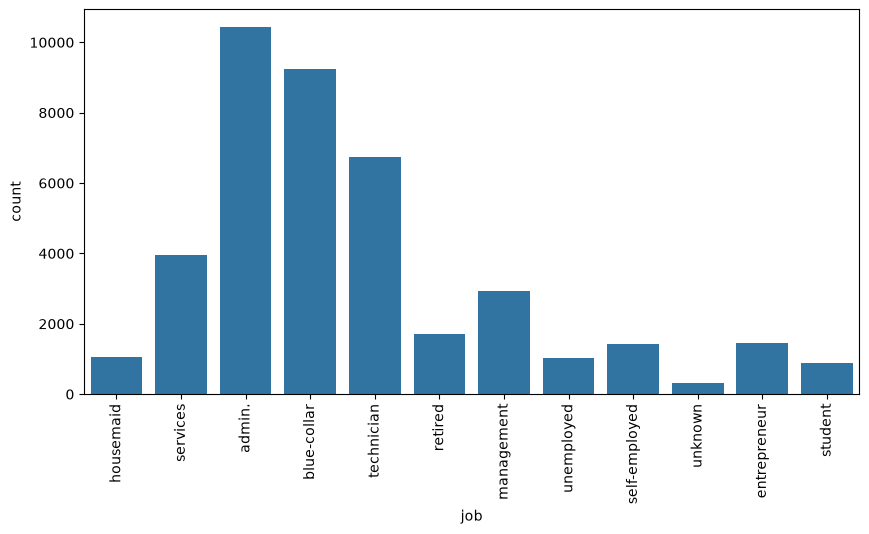

In [11]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "job")
plt.xticks(rotation = 90)
plt.show()

In [12]:
raw_df['job'].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [13]:
raw_df[raw_df['job'] == 'unknown']

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
29,55,unknown,married,university.degree,unknown,unknown,unknown,telephone,may,mon,362,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
35,55,unknown,married,basic.4y,unknown,yes,no,telephone,may,mon,336,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
73,57,unknown,married,unknown,unknown,no,no,telephone,may,mon,211,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
91,57,unknown,married,unknown,unknown,yes,no,telephone,may,mon,48,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
144,38,unknown,divorced,high.school,unknown,yes,no,telephone,may,mon,73,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40370,59,unknown,married,unknown,no,no,no,cellular,aug,wed,198,1,6,1,success,-1.70,94.03,-38.30,0.90,4991.60,yes
40428,64,unknown,married,unknown,no,yes,no,telephone,aug,fri,239,4,999,0,nonexistent,-1.70,94.03,-38.30,0.91,4991.60,yes
40656,67,unknown,divorced,unknown,unknown,yes,no,cellular,sep,wed,220,2,6,2,success,-1.10,94.20,-37.50,0.88,4963.60,yes
41005,63,unknown,married,professional.course,no,no,no,cellular,oct,thu,235,1,6,1,success,-1.10,94.60,-49.50,1.02,4963.60,no


### Аналіз стовпця `marital`

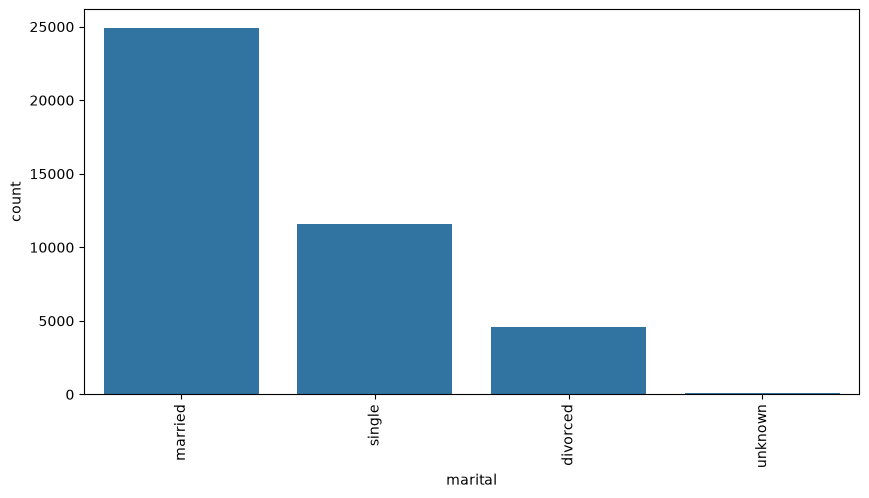

In [14]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "marital")
plt.xticks(rotation = 90)
plt.show()

### Аналіз стовпця `education`

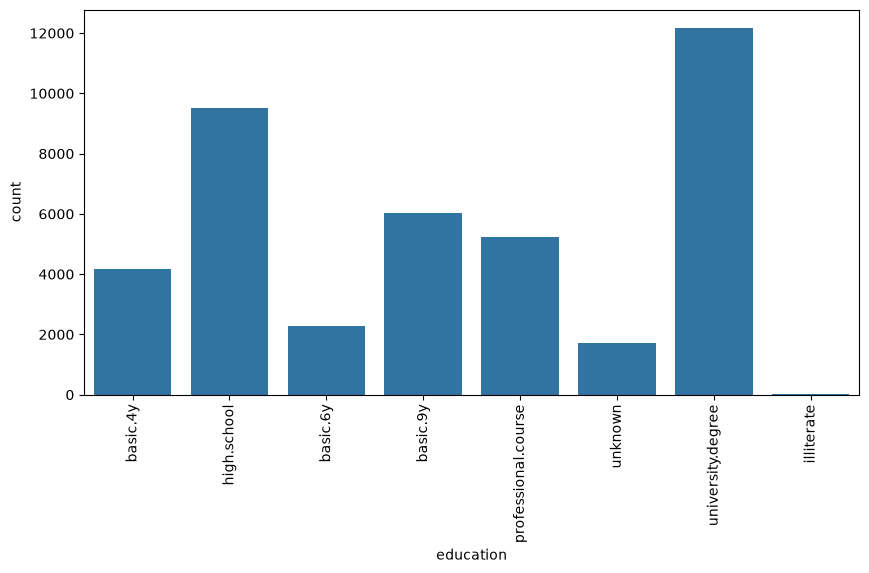

In [15]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "education")
plt.xticks(rotation = 90)
plt.show()

### Аналіз стовпця `default`

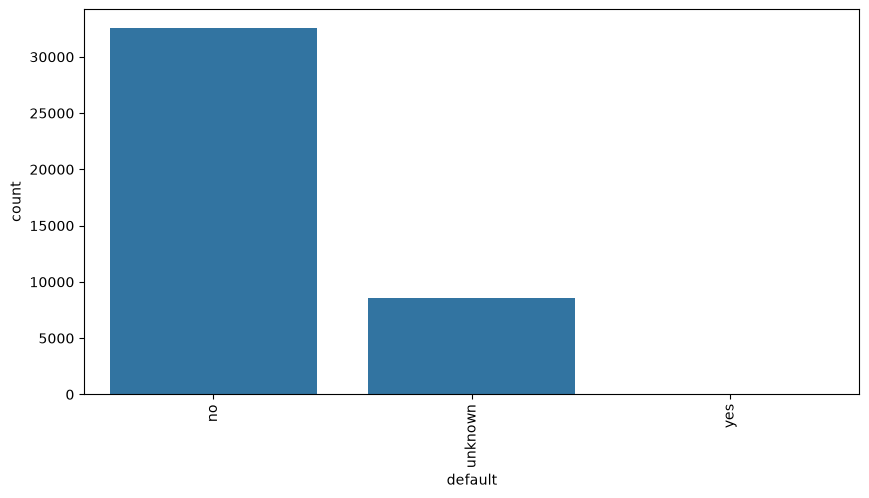

In [16]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "default")
plt.xticks(rotation = 90)
plt.show()

In [17]:
raw_df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

### Аналіз стовпця `housing`

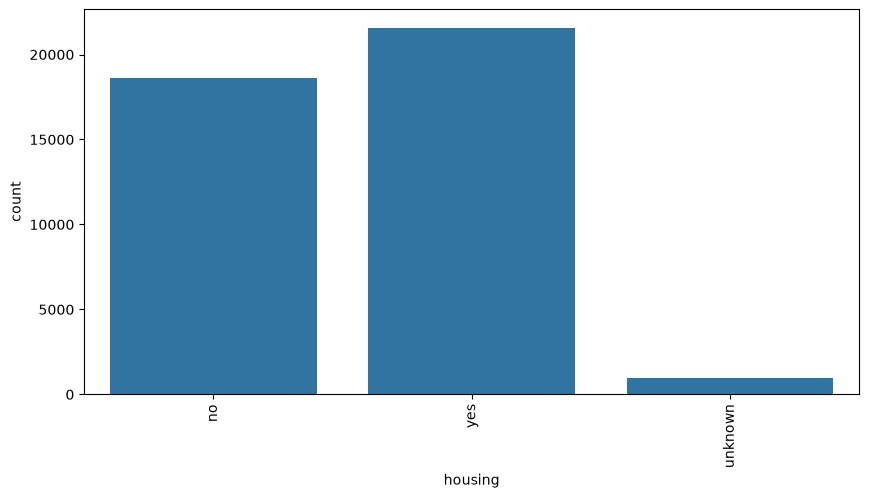

In [18]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "housing")
plt.xticks(rotation = 90)
plt.show()

### Аналіз стовпця `loan`

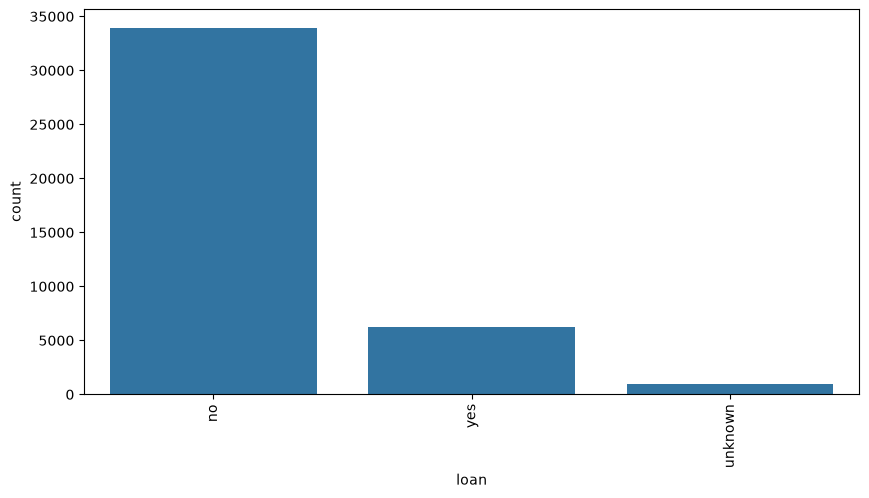

In [19]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "loan")
plt.xticks(rotation = 90)
plt.show()

### Аналіз стовпця `contact`

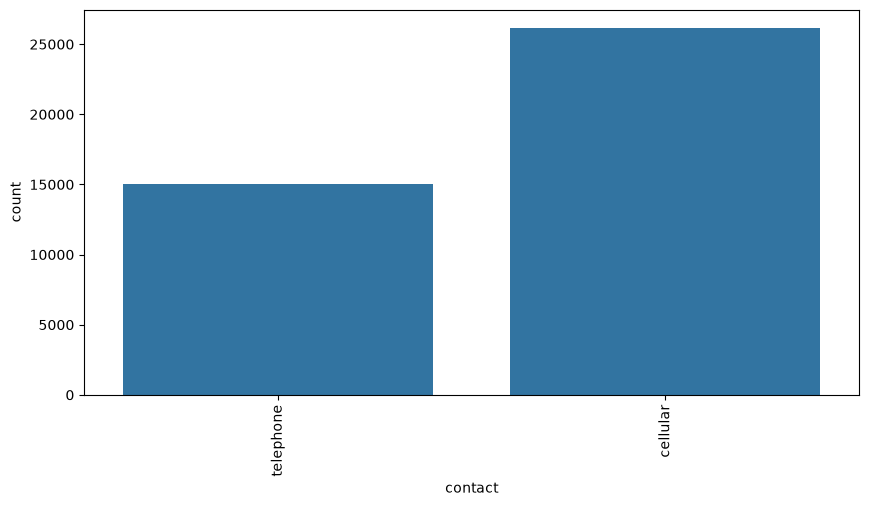

In [20]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "contact")
plt.xticks(rotation = 90)
plt.show()

### Аналіз стовпця `month`

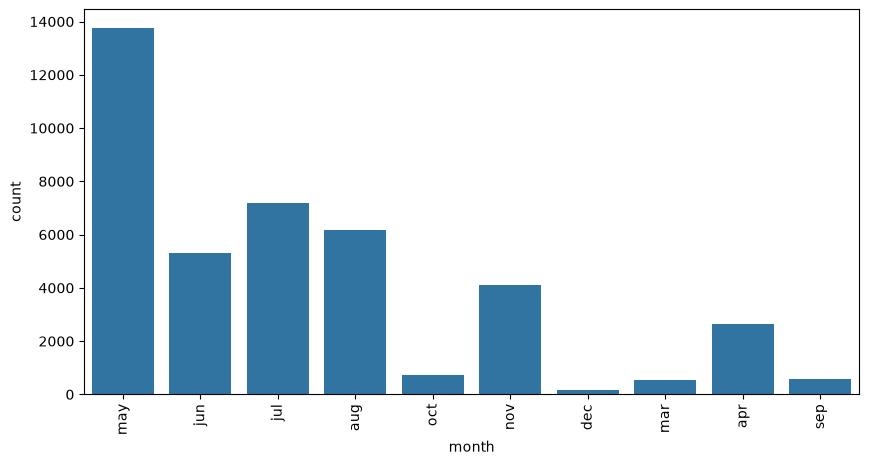

In [21]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "month")
plt.xticks(rotation = 90)
plt.show()

### Аналіз стовпця `day_of_week`

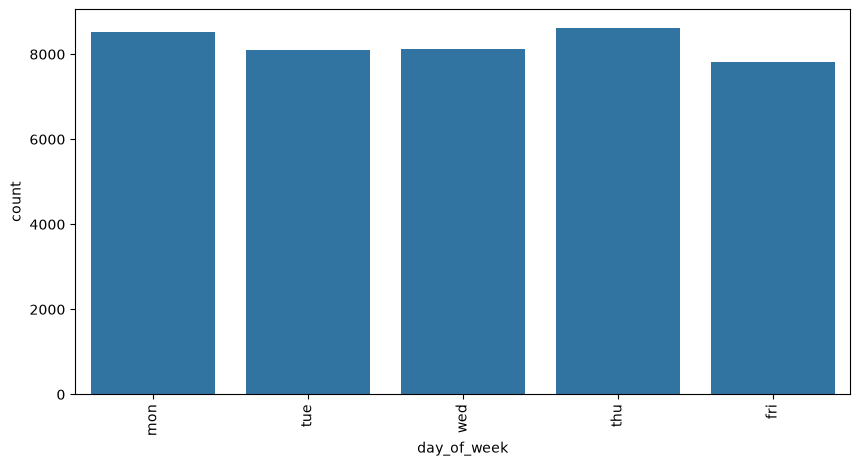

In [22]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "day_of_week")
plt.xticks(rotation = 90)
plt.show()

### Аналіз стовпця `poutcome`

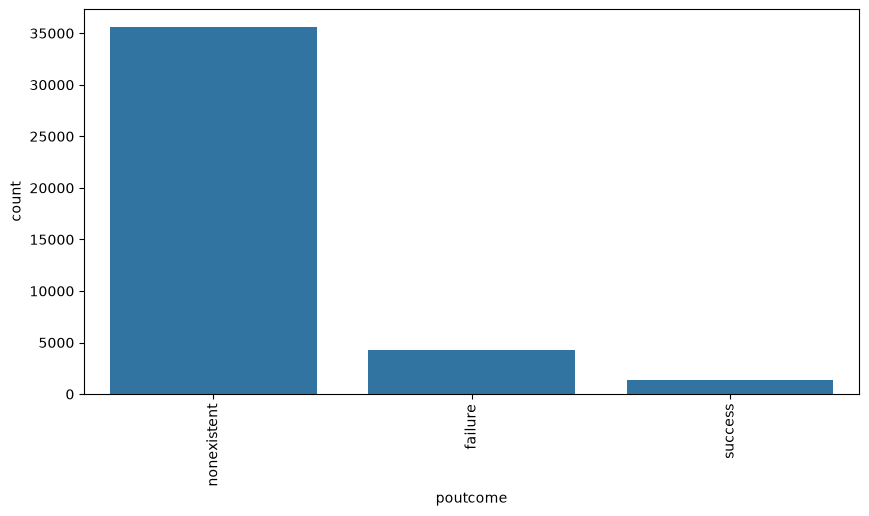

In [23]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "poutcome")
plt.xticks(rotation = 90)
plt.show()

### Аналіз стовпця `y`

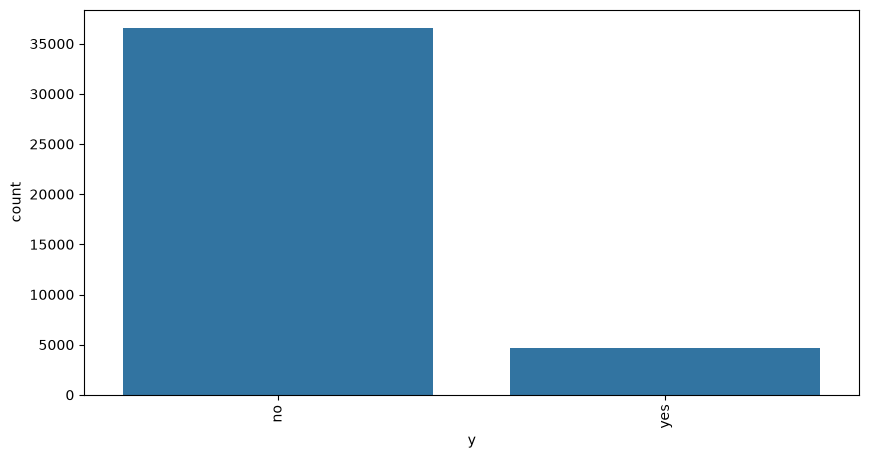

In [24]:
plt.figure(figsize = (10,5))
sns.countplot(data = raw_df, x = "y")
plt.xticks(rotation = 90)
plt.show()

In [25]:
raw_df['y'].value_counts(normalize=True)

y
no    0.89
yes   0.11
Name: proportion, dtype: float64

# Розподіл даних на основі `TARGET`

In [26]:
def bi_cat_countplot(df, column, hue_column):
    unique_hue_values = df[hue_column].unique()
    fig, axes = plt.subplots(nrows=1, ncols=2)
    fig.set_size_inches(14,6)

    pltname = f'Нормалізований розподіл значень за категорією: {column}'
    proportions = df.groupby(hue_column)[column].value_counts(normalize=True)
    proportions = (proportions*100).round(2)
    ax = proportions.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[0], title=pltname)

    # анотація значень в барплоті
    for container in ax.containers:
        ax.bar_label(container, fmt='{:,.1f}%')

    pltname = f'Кількість даних за категорією: {column}'
    counts = df.groupby(hue_column)[column].value_counts()
    ax = counts.unstack(hue_column).sort_values(
        by=unique_hue_values[0], ascending=False
        ).plot.bar(ax=axes[1], title=pltname)

    for container in ax.containers:
      ax.bar_label(container)

In [27]:
def uni_cat_target_compare(df, column):
    bi_cat_countplot(df, column, hue_column='y')

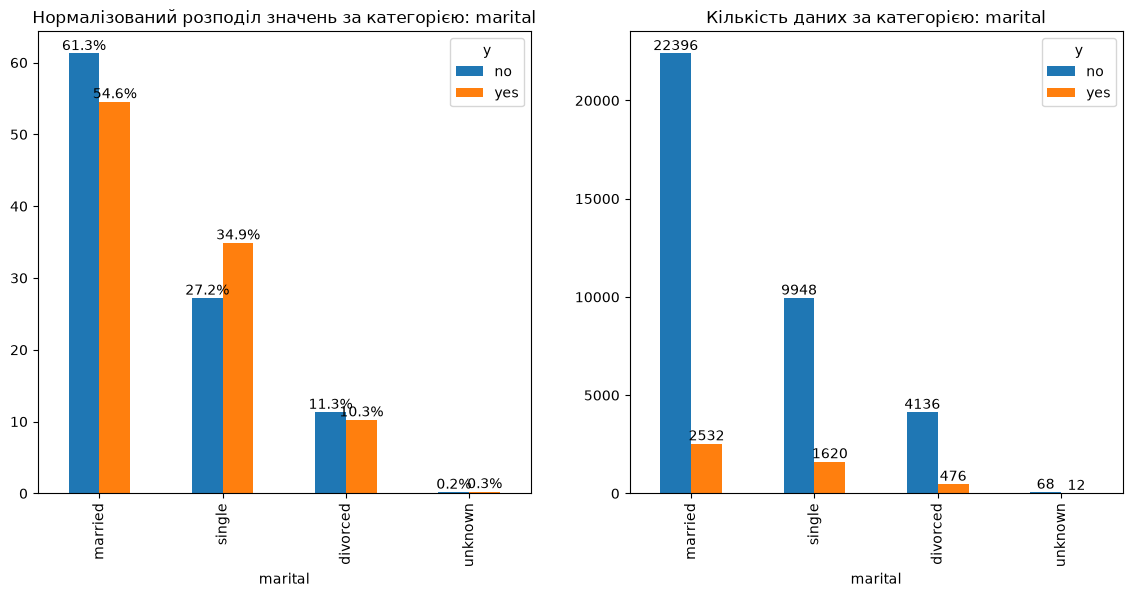

In [28]:
uni_cat_target_compare(raw_df, 'marital')

Частіше погоджуються на депозит клієнти з категорії single.

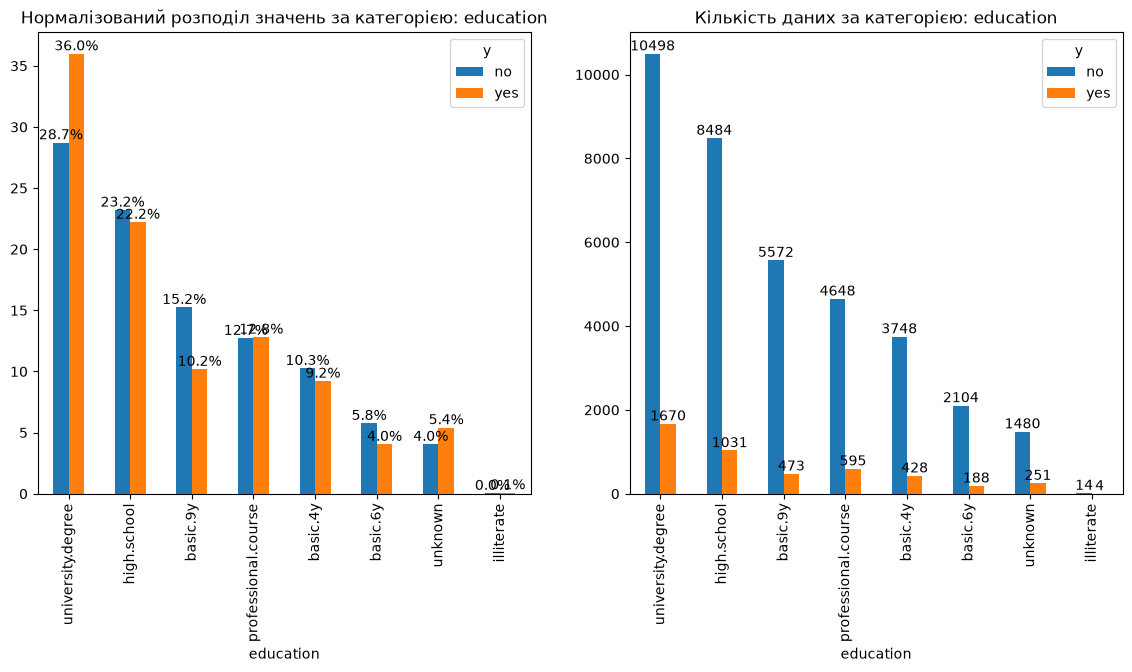

In [29]:
uni_cat_target_compare(raw_df, 'education')

Частіше погоджуються на депозит клієнти з категорії вищою університетською освітою.

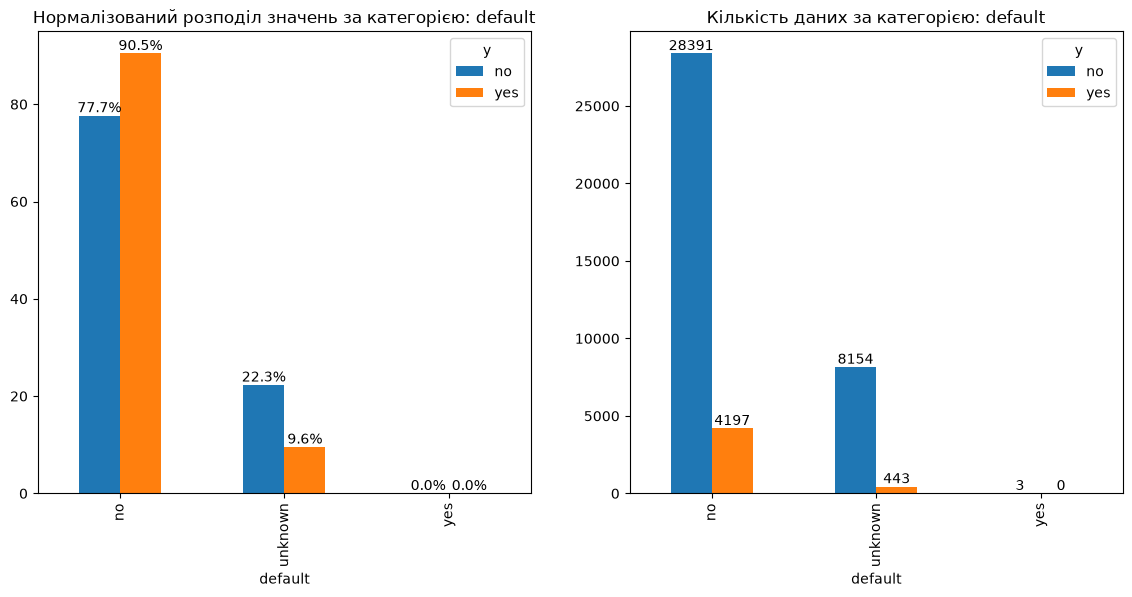

In [30]:
uni_cat_target_compare(raw_df, 'default')

Найчастіше погоджуються ті, у кого немає простроченого депозиту.

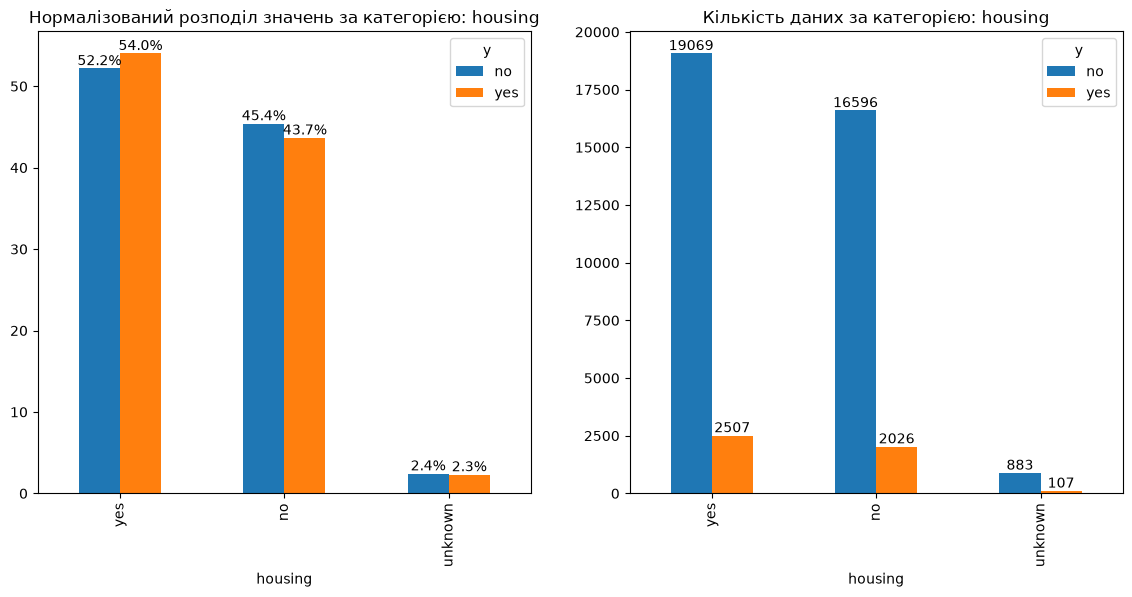

In [31]:
uni_cat_target_compare(raw_df, 'housing')

Ознака housing не має вираженої кореляції з таргетом.

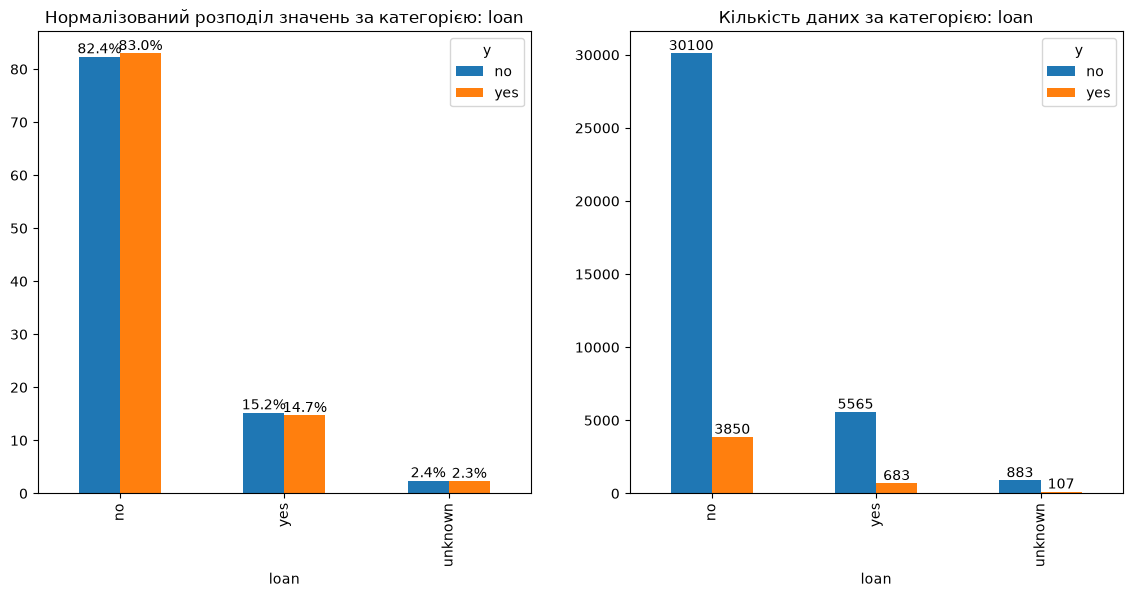

In [32]:
uni_cat_target_compare(raw_df, 'loan')

Ознака loan не має вираженої кореляції з таргетом.

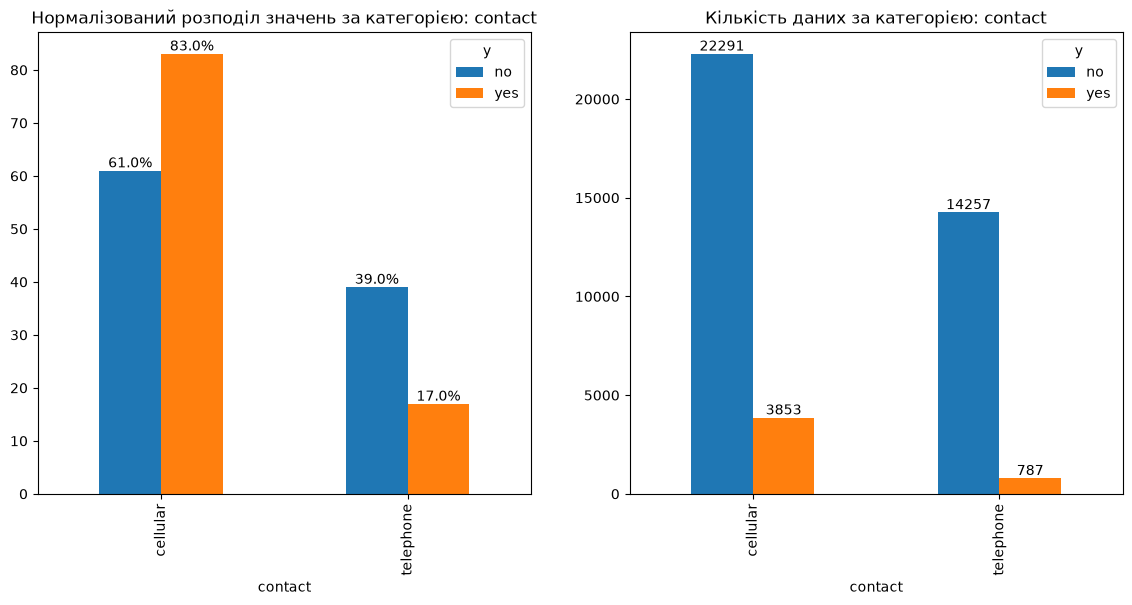

In [33]:
uni_cat_target_compare(raw_df, 'contact')

Ті, з ким контактували через мобільний телефон більш схильні до відкриття депозиту.

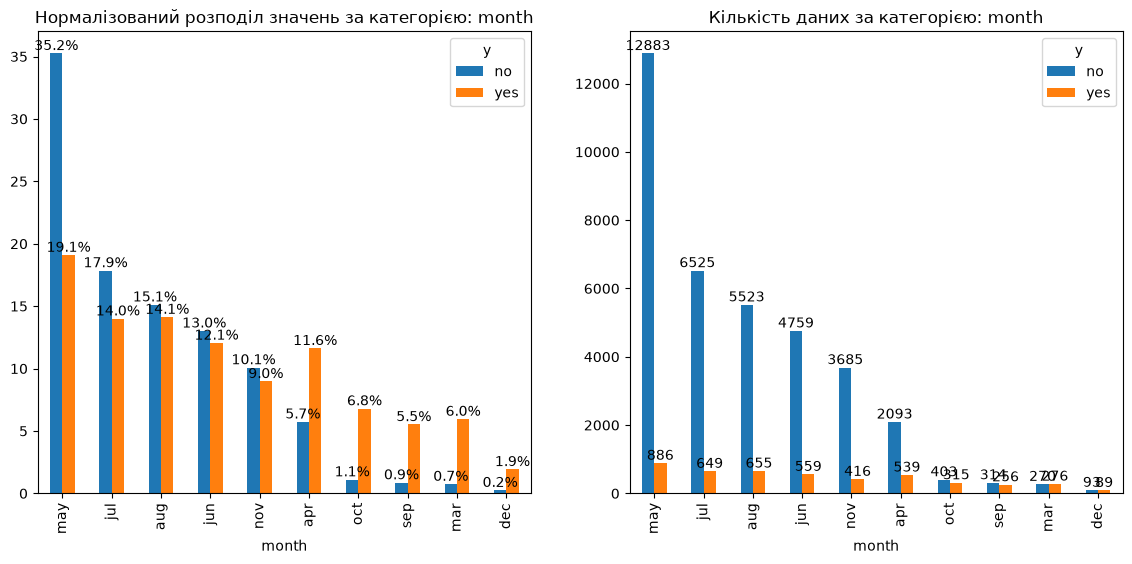

In [34]:
uni_cat_target_compare(raw_df, 'month')

Найчасіше люди схільні до відкриття депозитів в квітні, жовтні, вересні, березні і в грудні.

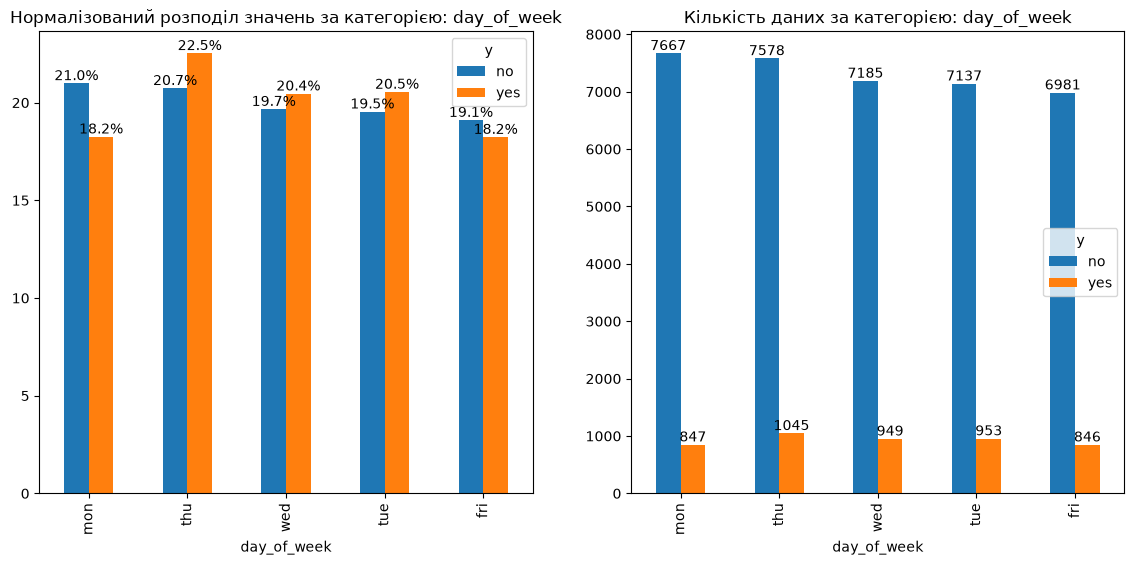

In [35]:
uni_cat_target_compare(raw_df, 'day_of_week')

Клієнти найменш схильні до відкриття депозиту в понеділок та в п'ятницю.

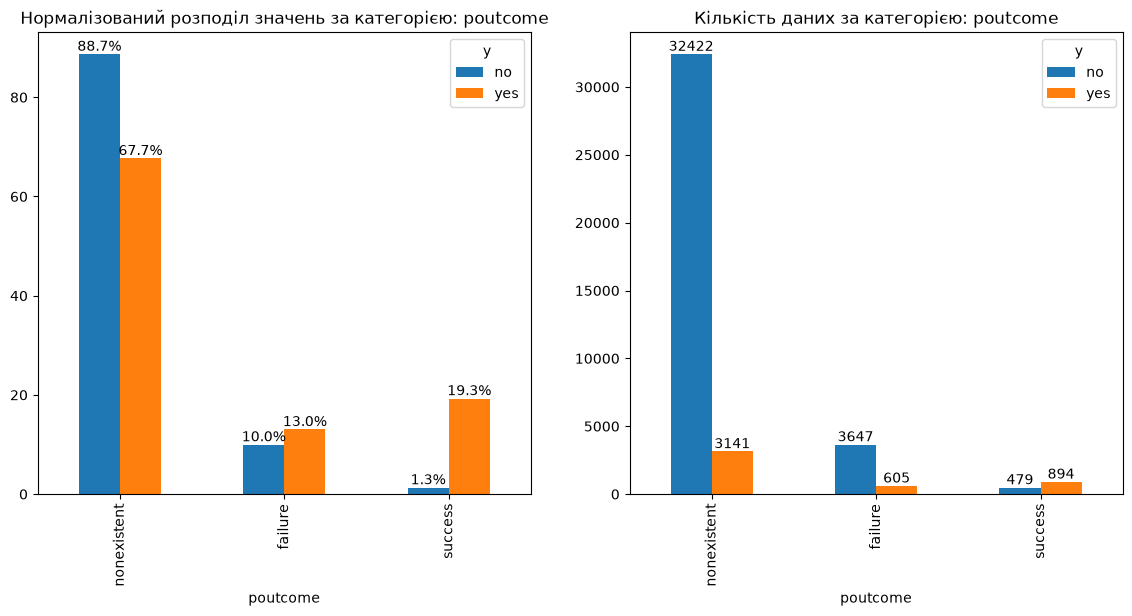

In [36]:
uni_cat_target_compare(raw_df, 'poutcome')

Клієнти найменш схильні до відкриття депозиту, якщо був якийсь результат попередньої кампанії, особливо "success".

In [37]:
import warnings

def dist_box(dataset, column):
    with warnings.catch_warnings():
      warnings.simplefilter("ignore")

      plt.figure(figsize=(16,6))

      plt.subplot(1,2,1)
      sns.distplot(dataset[column], color = 'purple')
      pltname = 'Графік розподілу для ' + column
      plt.ticklabel_format(style='plain', axis='x')
      plt.title(pltname)

      plt.subplot(1,2,2)
      red_diamond = dict(markerfacecolor='r', marker='D')
      sns.boxplot(y = column, data = dataset, flierprops = red_diamond)
      pltname = 'Боксплот для ' + column
      plt.title(pltname)

      plt.show()

In [38]:
number_df.columns.tolist()

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

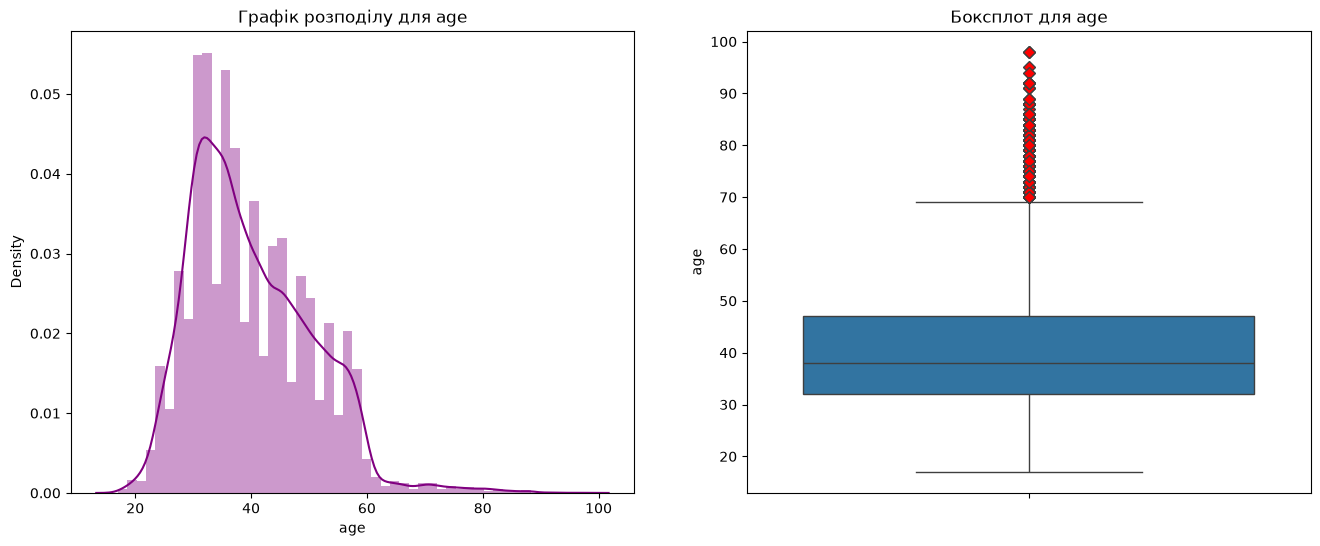

In [39]:
dist_box(raw_df,'age')

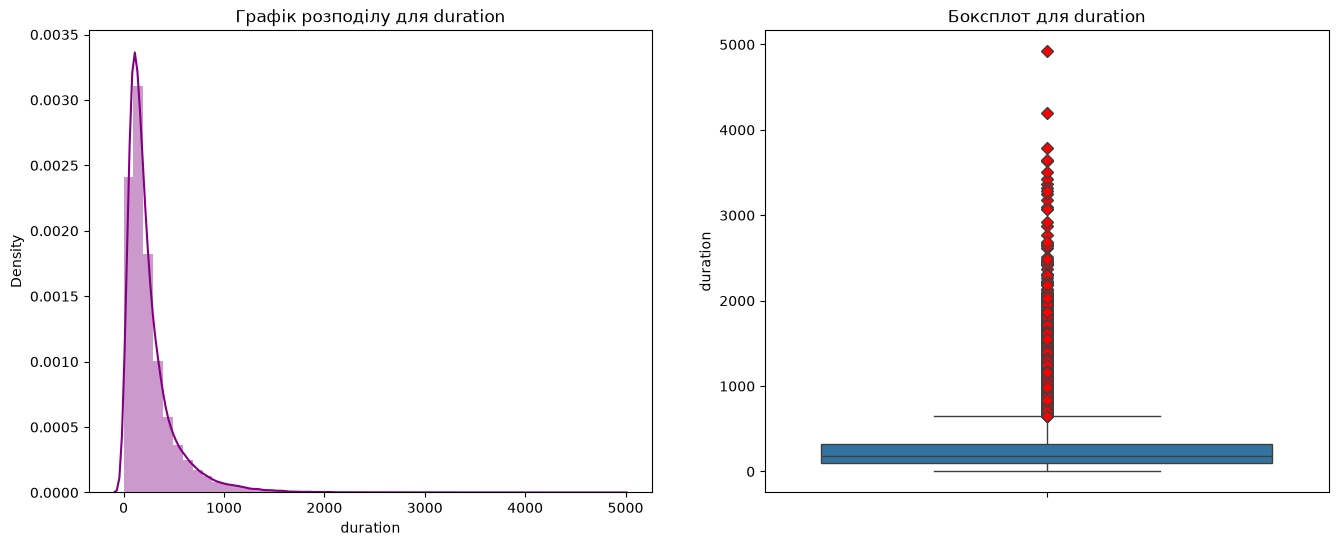

In [40]:
dist_box(raw_df,'duration')

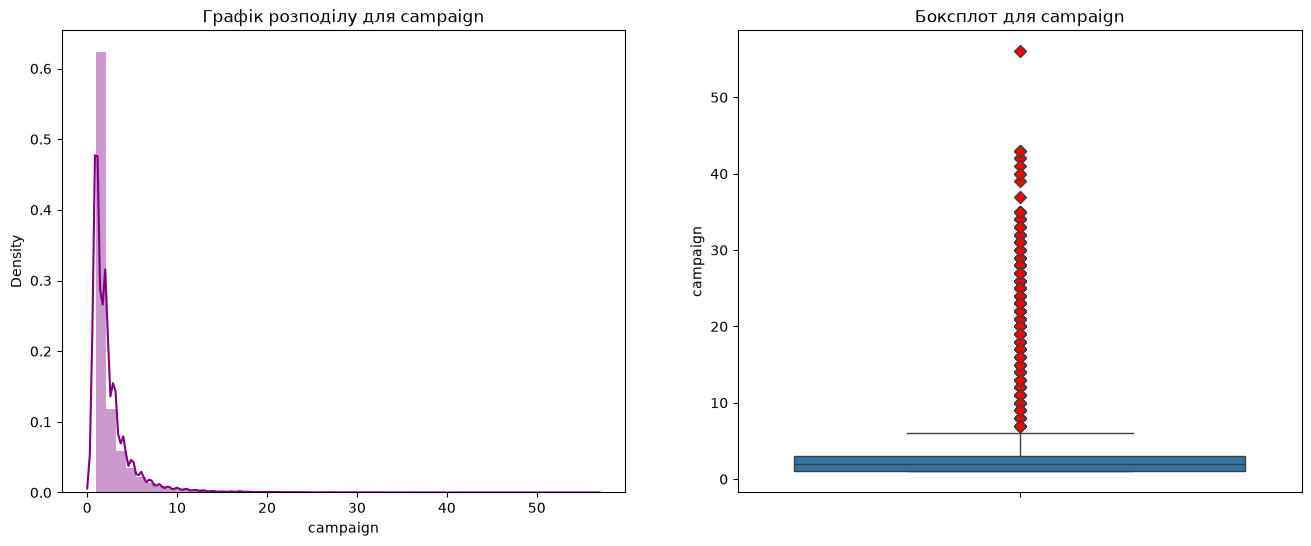

In [41]:
dist_box(raw_df,'campaign')

Викиди є, але вони виглядають адекватними.

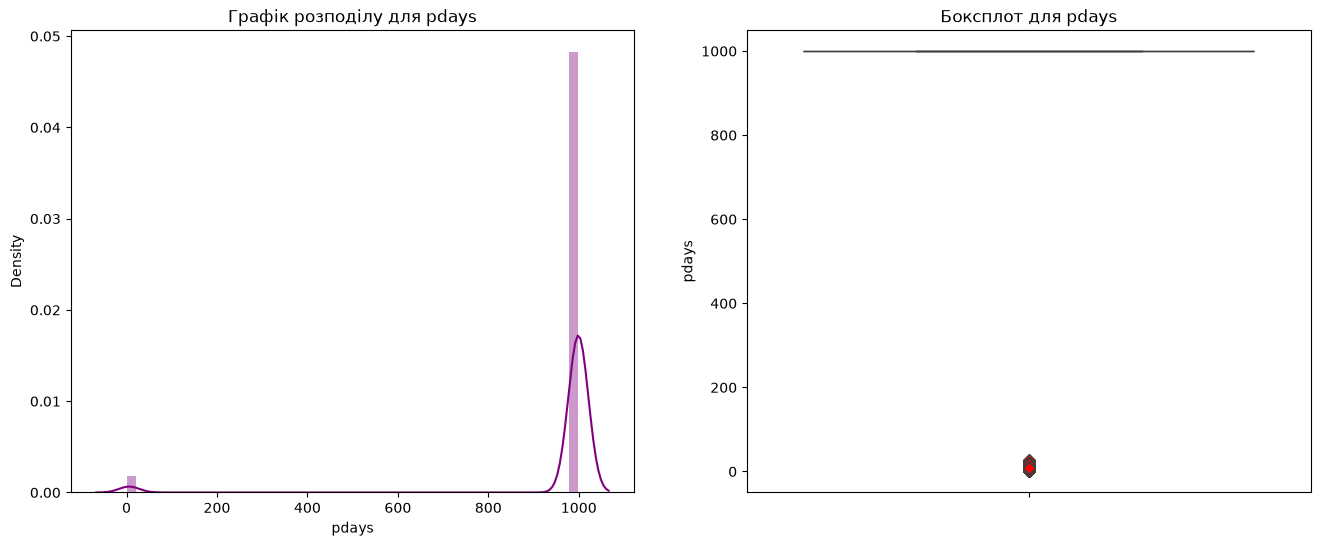

In [42]:
dist_box(raw_df,'pdays')

In [43]:
raw_df['pdays'].value_counts()

pdays
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64

Для логістичної регресії, можливо, є сенс замінити значення 999 на -1

In [44]:
raw_df['pdays'] = raw_df['pdays'].replace(999,-1)

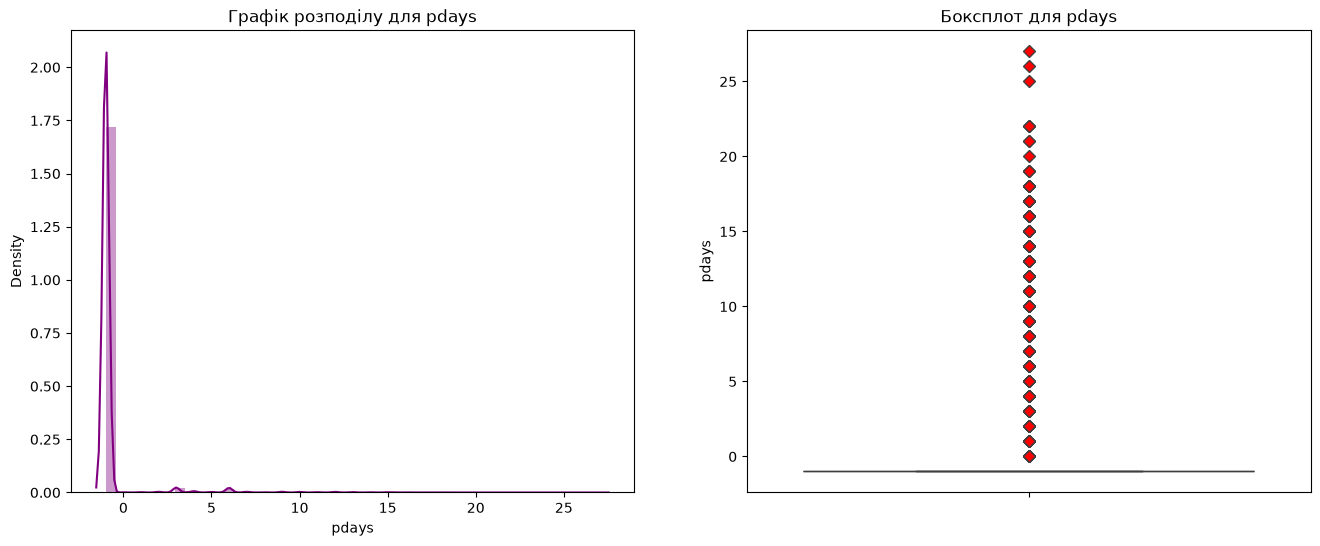

In [45]:
dist_box(raw_df,'pdays')

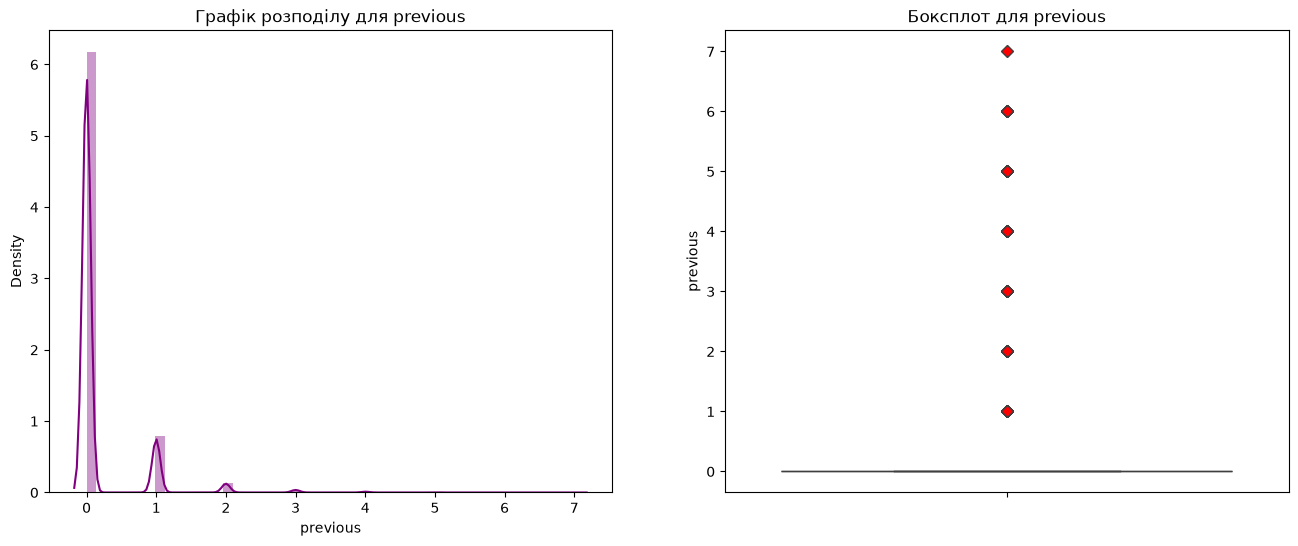

In [46]:
dist_box(raw_df,'previous')

Викиди є, але вони виглядають адекватними.

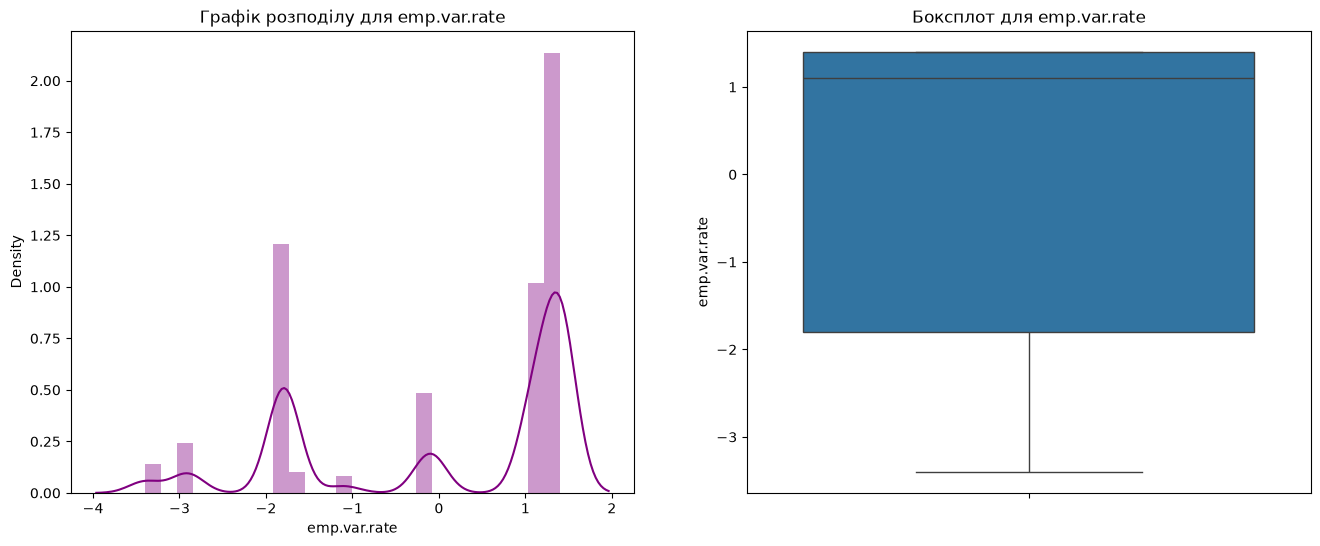

In [47]:
dist_box(raw_df,'emp.var.rate')

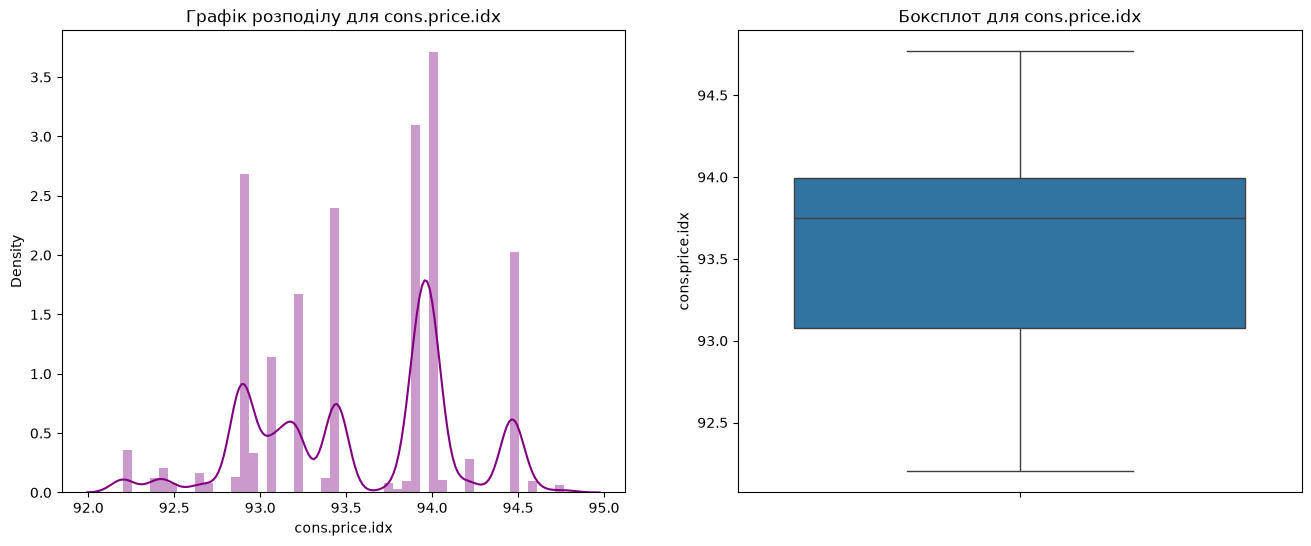

In [48]:
dist_box(raw_df,'cons.price.idx')

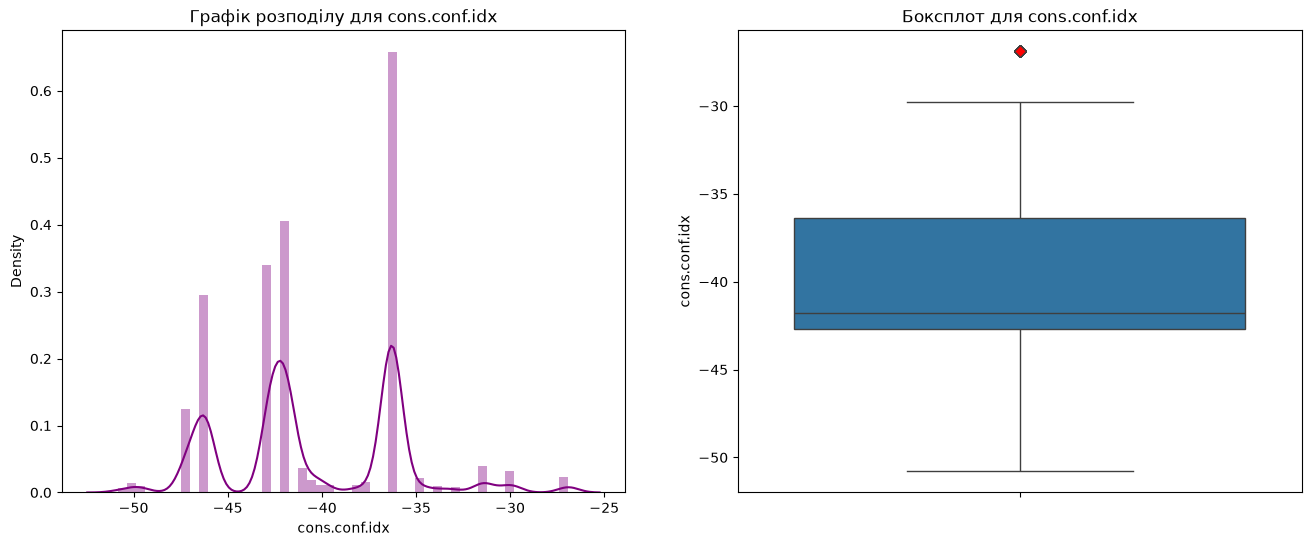

In [49]:
dist_box(raw_df,'cons.conf.idx')

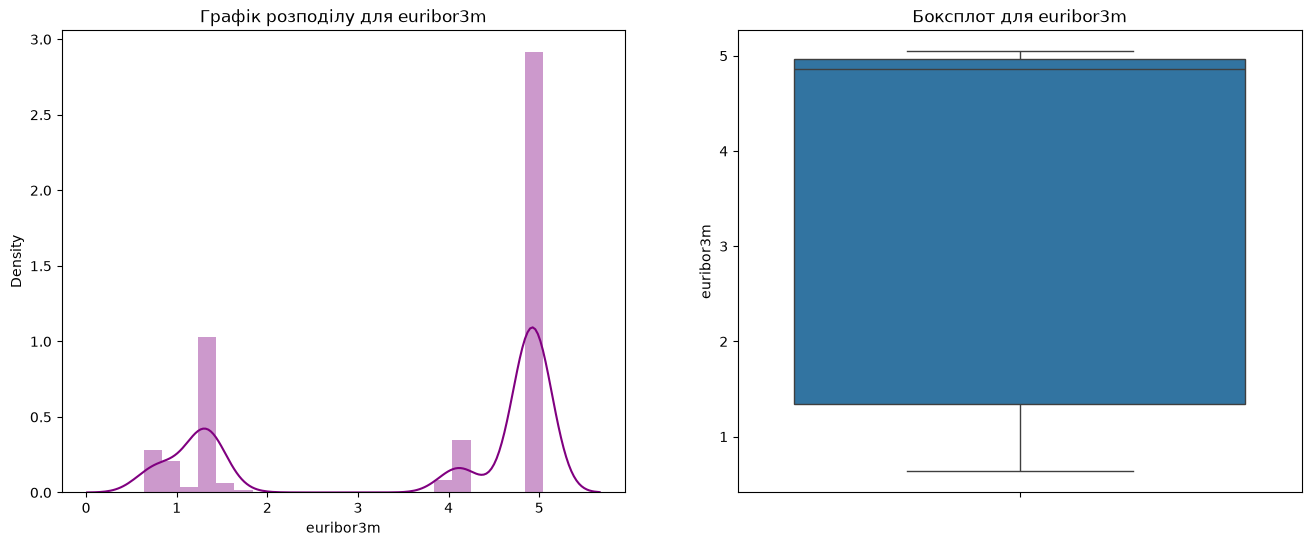

In [50]:
dist_box(raw_df,'euribor3m')

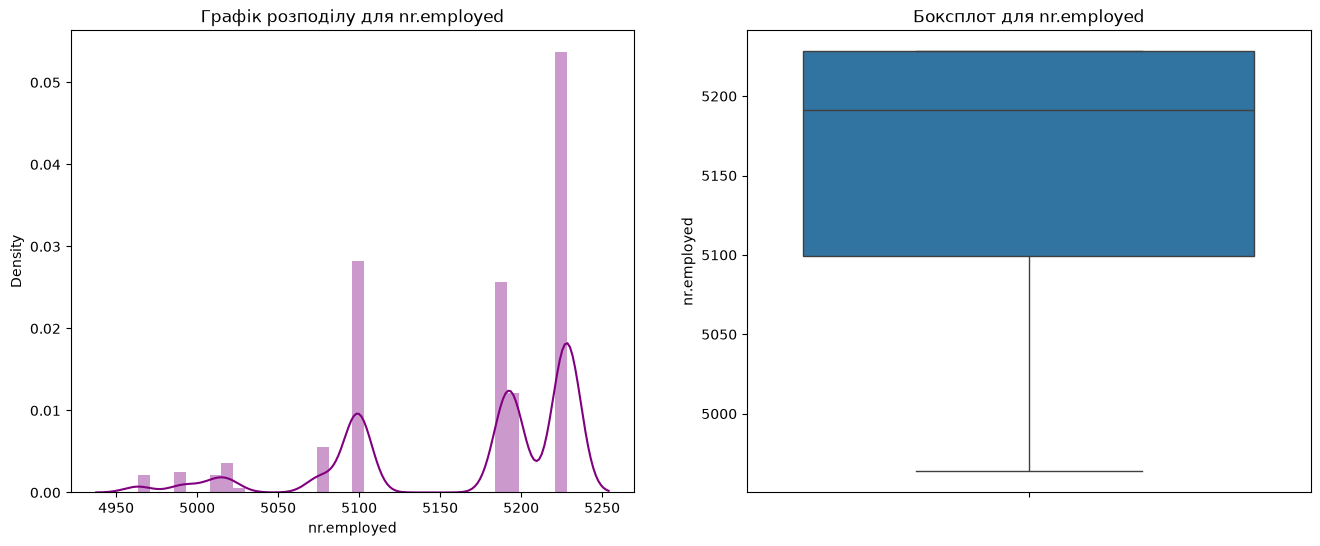

In [51]:
dist_box(raw_df,'nr.employed')

Викидів майже немає.

# Кореляційний аналіз числових змінних

In [52]:
raw_df.select_dtypes(include='number').shape

(41188, 10)

In [53]:
raw_df1 = raw_df[raw_df['y'] == 'yes']

In [54]:
raw_df0 = raw_df[raw_df['y'] == 'no']

In [55]:
corr_raw_df = raw_df1.select_dtypes(include='number').corr()

In [56]:
corr_raw_df.head()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
age,1.00,-0.06,-0.01,0.04,0.07,-0.08,-0.02,0.14,-0.09,-0.11
duration,-0.06,1.00,0.16,-0.18,-0.23,0.50,0.24,-0.14,0.50,0.48
campaign,-0.01,0.16,1.00,-0.08,-0.10,0.22,0.12,-0.04,0.21,0.20
pdays,0.04,-0.18,-0.08,1.00,0.61,-0.22,0.09,0.13,-0.31,-0.40
previous,0.07,-0.23,-0.10,0.61,1.00,-0.28,0.09,0.13,-0.39,-0.49


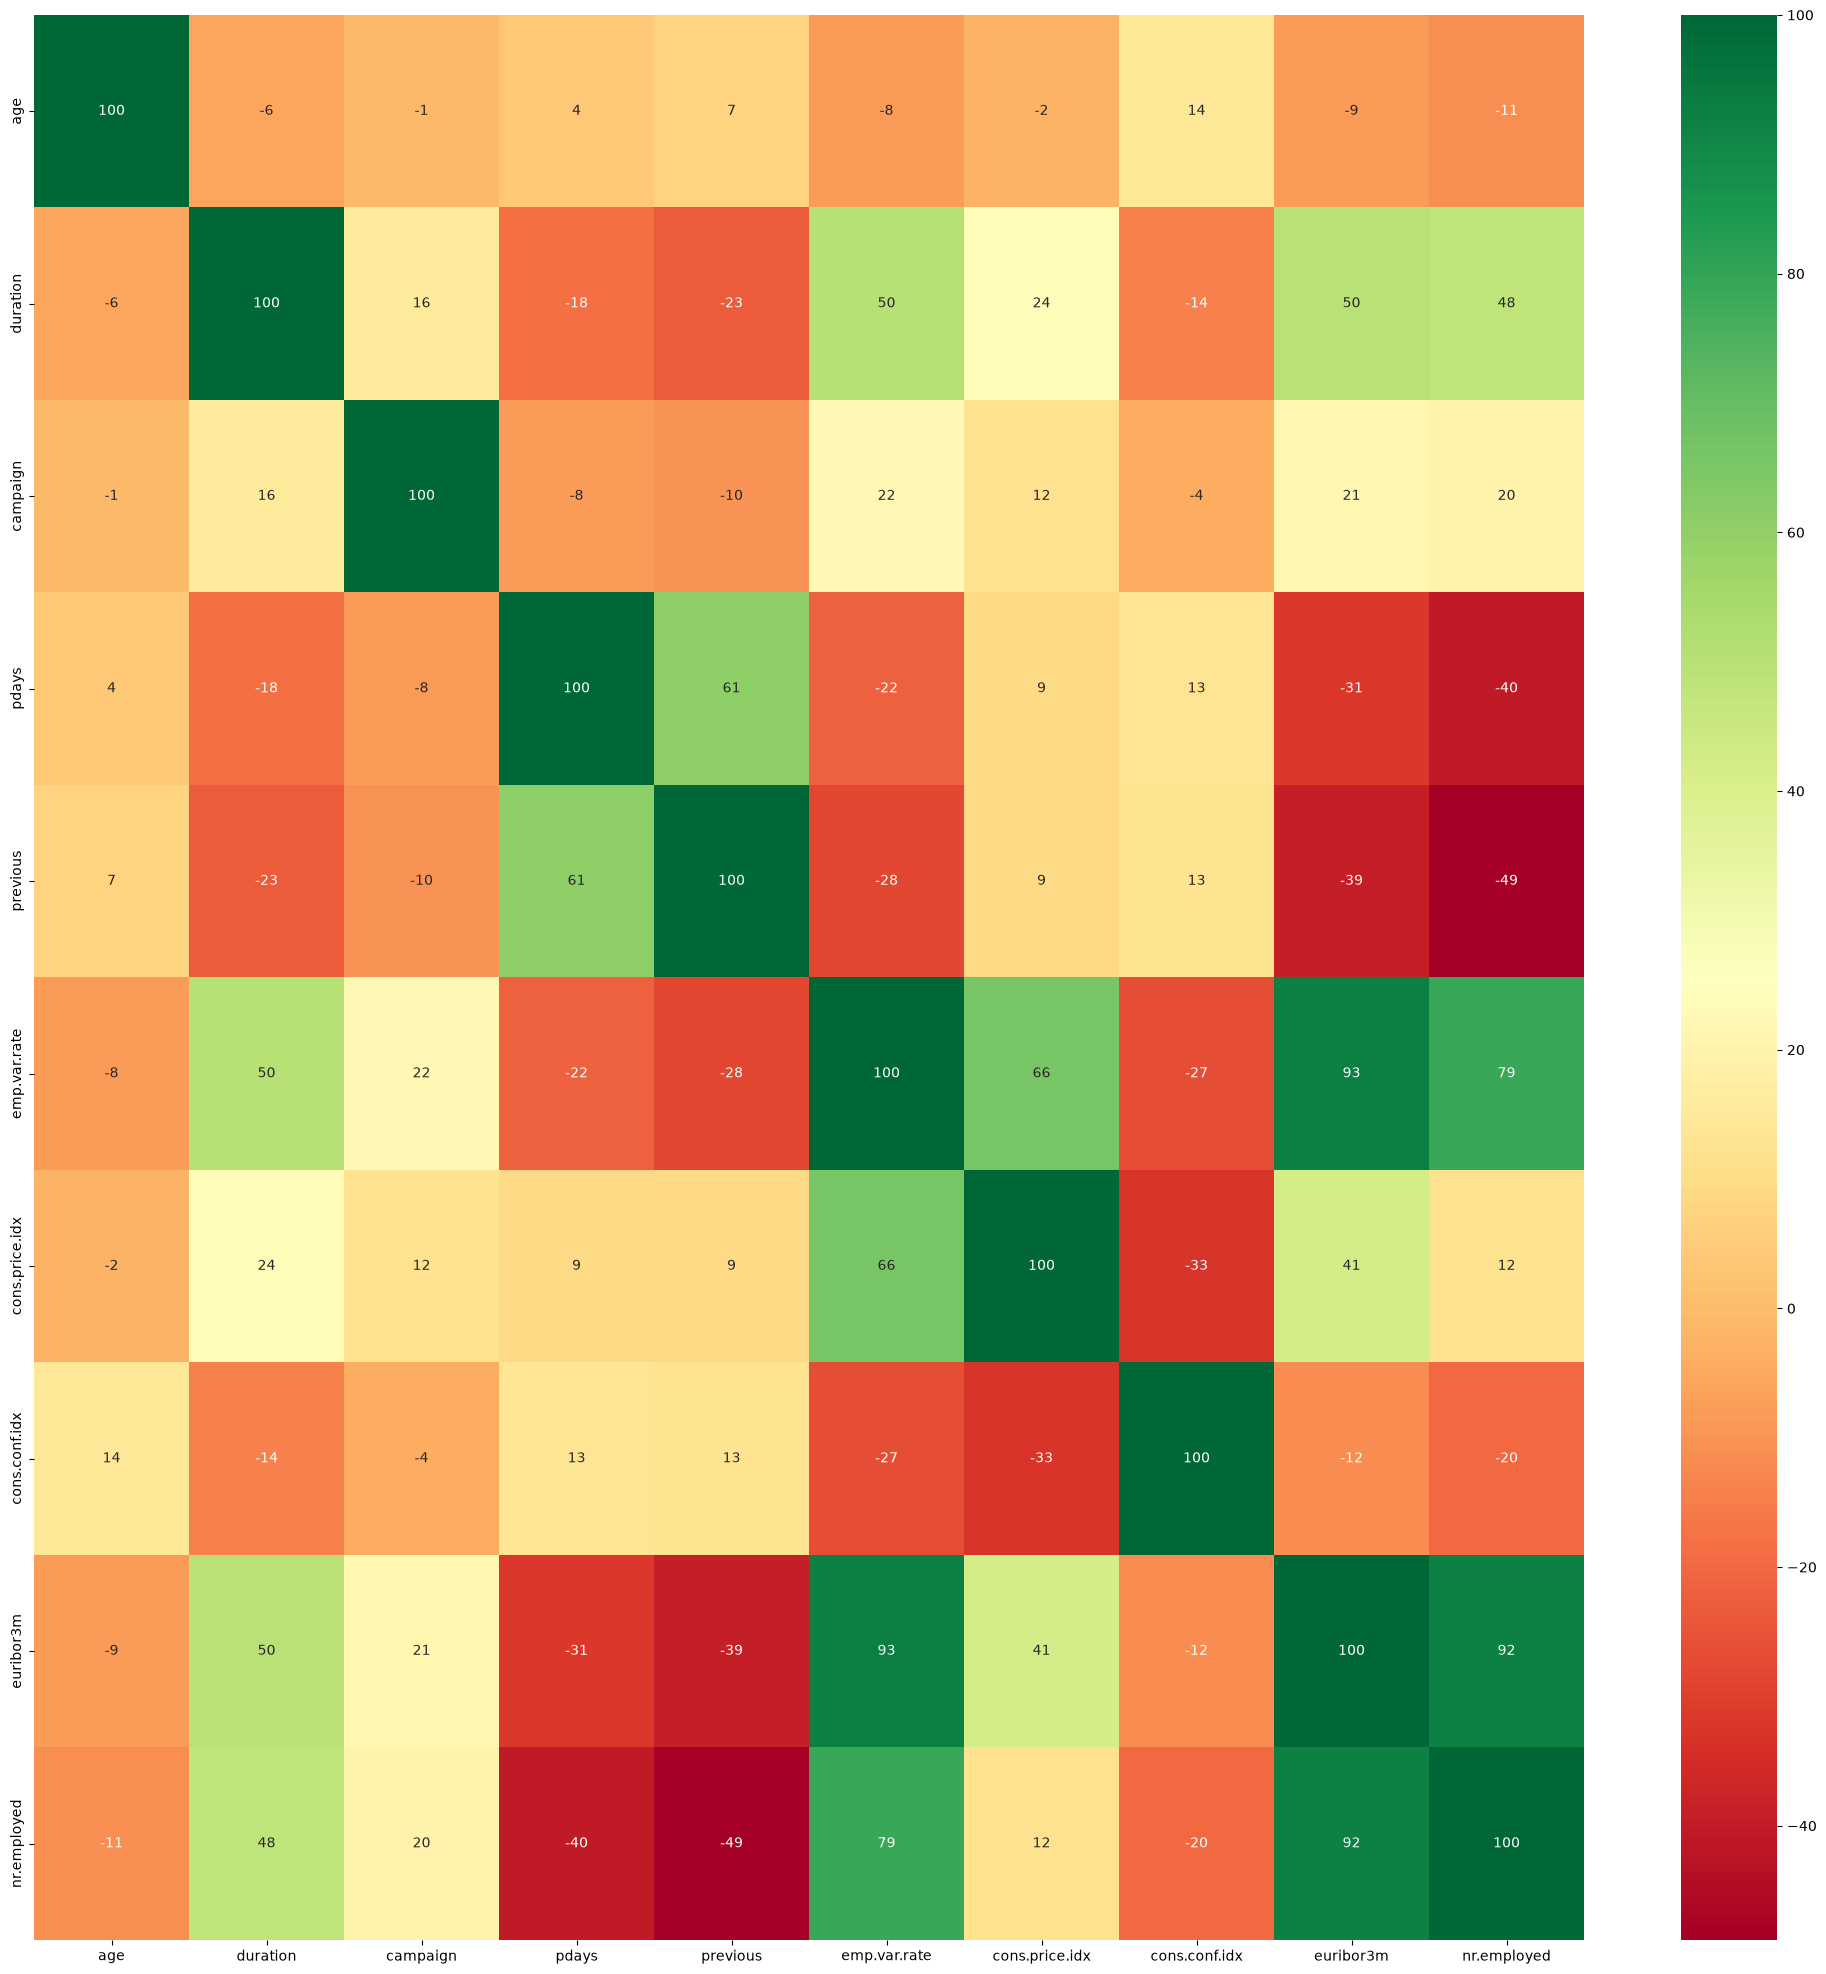

In [57]:
plt.figure(figsize = (25,25))
sns.heatmap(data = corr_raw_df*100, annot = True, cmap = "RdYlGn", cbar = True, fmt='.0f')
plt.show()

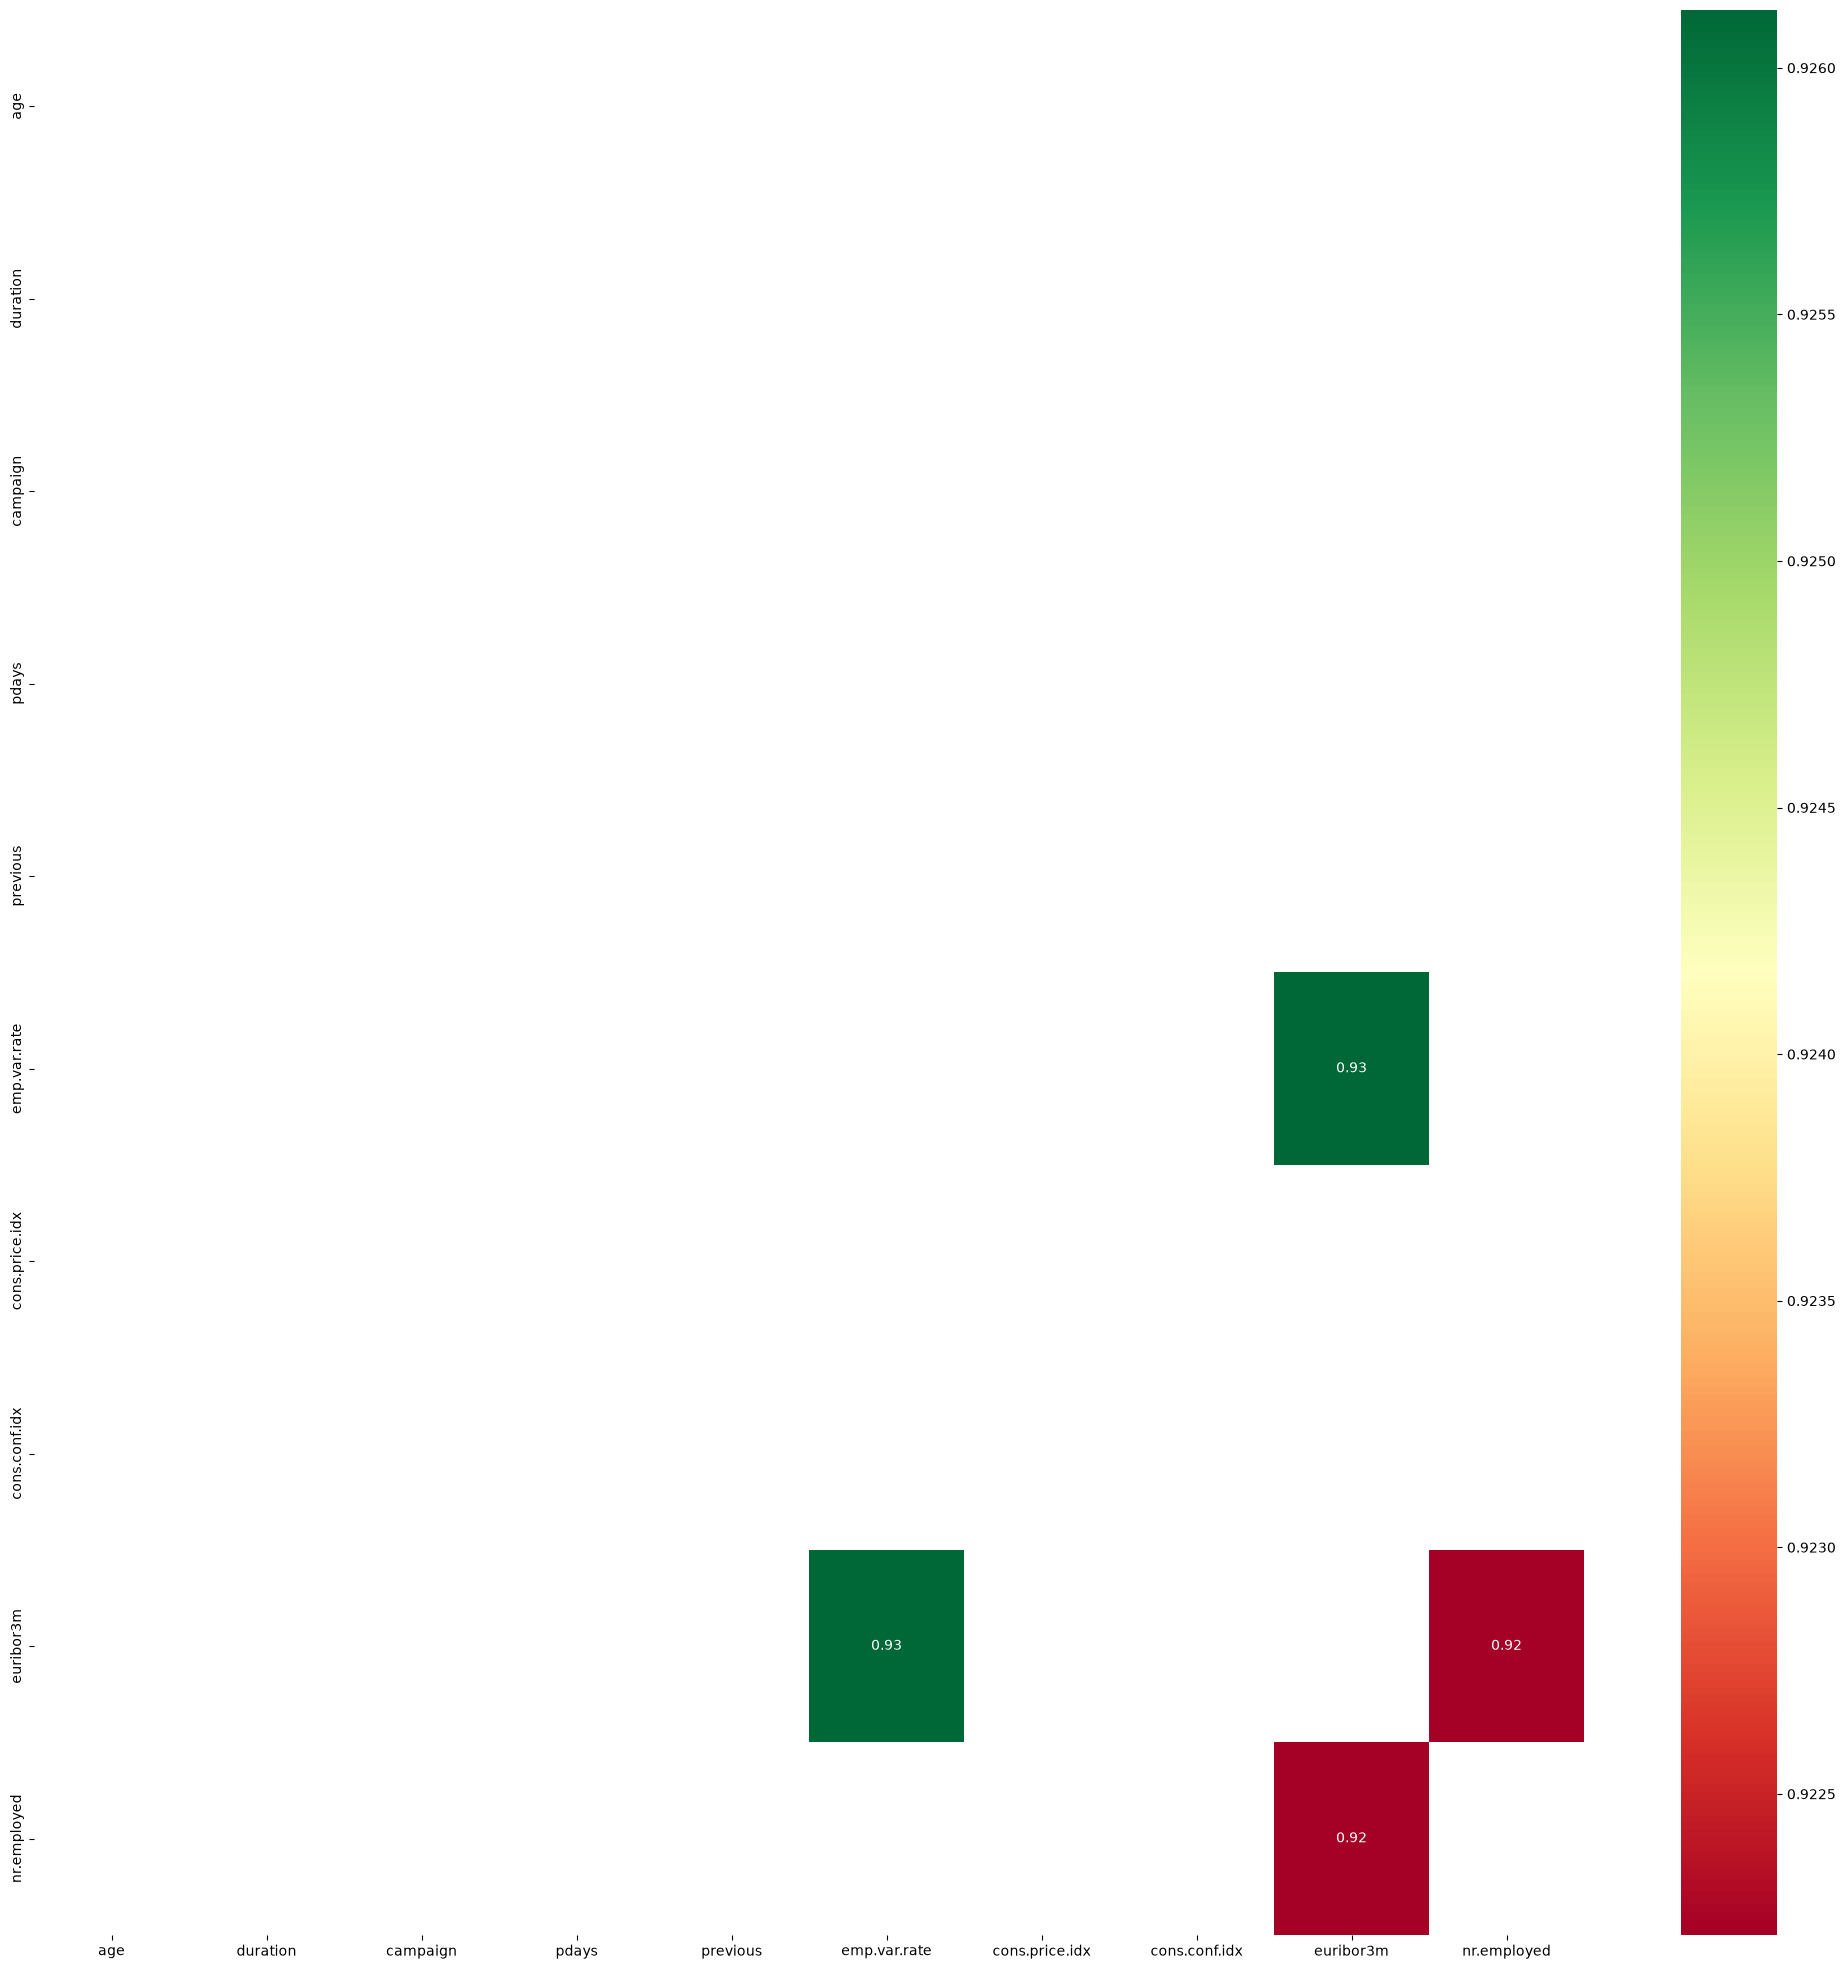

In [58]:
plt.figure(figsize = (25,25))
sns.heatmap(data = corr_raw_df[(corr_raw_df >= 0.8) & (corr_raw_df < 0.99)], annot = True, cmap = "RdYlGn", cbar = True, fmt='.2f')
plt.show()

Основною метрикою обираємо ROC-AUC, оскільки target є незбалансованим і Accuracy може створювати хибне враження про якість моделі. ROC-AUC оцінює здатність моделі ранжувати позитивні та негативні приклади незалежно від конкретного threshold.

### Ligistic regression

In [59]:
df_logr = raw_df.drop(columns = ['duration'])

In [60]:
df_logr.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,-1,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,-1,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,-1,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,-1,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,-1,0,nonexistent,1.10,93.99,-36.40,4.86,5191.00,no


In [61]:
df_logr['y'] = df_logr['y'].map({'yes': 1, 'no': 0})

In [62]:
df_logr['y'].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

In [63]:
train_df, val_df = train_test_split(df_logr, test_size=0.2, random_state=42, stratify = df_logr['y'])

In [64]:
train_df.shape

(32950, 20)

In [65]:
# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[0:-1]
target_col = 'y'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets =  val_df[input_cols].copy(), val_df[target_col].copy()

In [66]:
# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist() 
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [67]:
# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('PolynomialFeatures', PolynomialFeatures(degree=3))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = ImPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTETomek(random_state=42)),
    ('classifier', LogisticRegression(solver='liblinear',C=10))
])

In [68]:
# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

,steps,"[('preprocessor', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


In [69]:
# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict_proba(inputs)[:,1]
    preds_binary = (preds >= 0.5).astype(int)
    accuracy = accuracy_score(targets, preds_binary)
    print("Accuracy: {:.2f}%".format(accuracy * 100))
    
    fpr, tpr, thresholds = roc_curve(targets, preds, pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.4f}")

    f1_score_ = f1_score(targets, preds_binary, pos_label=1)
    print(f"f1_score: {f1_score_:.4f}")
   
    confusion_matrix_ = confusion_matrix(targets, preds_binary, normalize='true')
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()

    return preds

Accuracy: 81.87%
Area under ROC score on Training dataset: 0.7977
f1_score: 0.4432


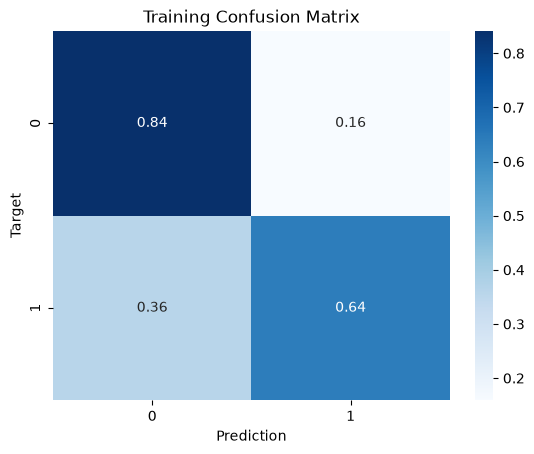

Accuracy: 82.68%
Area under ROC score on Validation dataset: 0.8062
f1_score: 0.4657


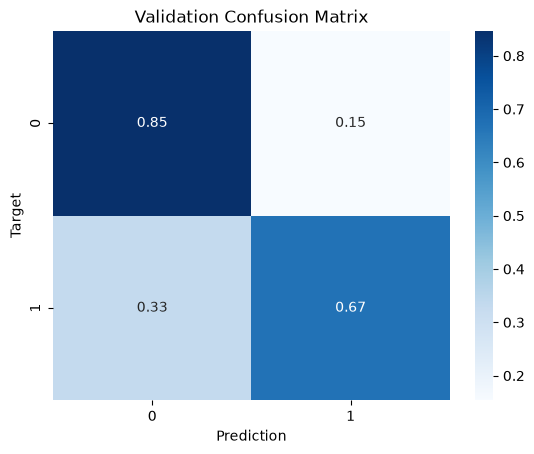

In [70]:
# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, name='Training')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, name='Validation')

# kNN

In [187]:
df_knn = raw_df.drop(columns = ['duration'])

In [188]:
df_knn['y'] = df_knn['y'].map({'yes': 1, 'no': 0})

In [196]:
train_df, val_df = train_test_split(df_knn, test_size=0.2, random_state=42, stratify = df_knn['y'])

In [197]:
# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[0:-1]
target_col = 'y'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets =  val_df[input_cols].copy(), val_df[target_col].copy()

In [198]:
# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist() 
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [199]:
# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = ImPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomOverSampler(random_state=42)),
    ('classifier', KNeighborsClassifier(n_neighbors = 120))
])

In [200]:
# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

,steps,"[('preprocessor', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


Accuracy: 80.72%
Area under ROC score on Training dataset: 0.8114
f1_score: 0.4346


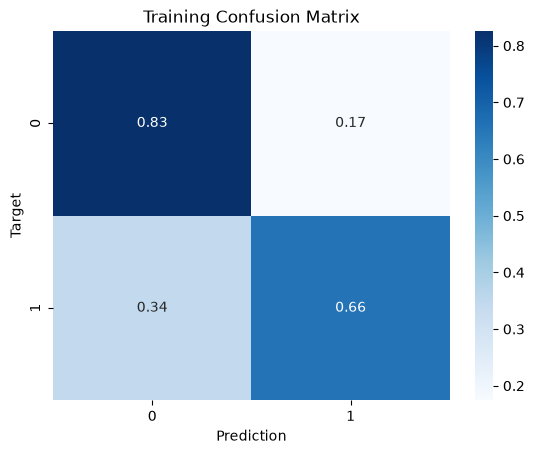

Accuracy: 80.67%
Area under ROC score on Validation dataset: 0.7856
f1_score: 0.4306


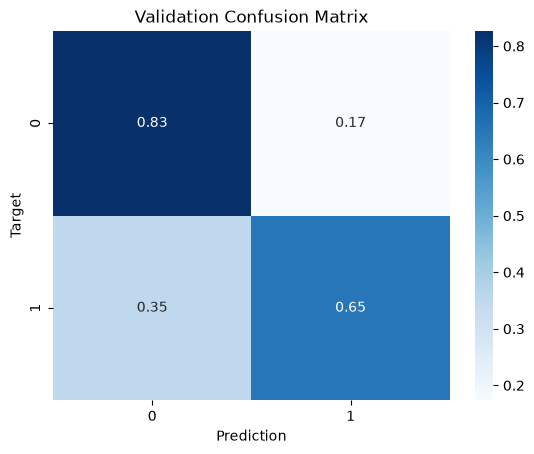

In [201]:
# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, name='Training')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, name='Validation')

# Decision Tree

In [202]:
df_dt = raw_df.drop(columns = ['duration'])

In [203]:
df_dt['y'] = df_dt['y'].map({'yes': 1, 'no': 0})

In [204]:
train_df, val_df = train_test_split(df_dt, test_size=0.2, random_state=42, stratify = df_dt['y'])

In [205]:
# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[0:-1]
target_col = 'y'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets =  val_df[input_cols].copy(), val_df[target_col].copy()

In [222]:
# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist() 
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [233]:
def max_depth_error(md):
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
    )

    model_pipeline = ImPipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=md, random_state=42))
    ])

    model_pipeline.fit(train_inputs, train_targets)

    train_error = 1 - model_pipeline.score(train_inputs, train_targets)
    val_error = 1 - model_pipeline.score(val_inputs, val_targets)

    return {'Max Depth': md, 'Training Error': train_error, 'Validation Error': val_error}

In [234]:
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1, 21)])

In [236]:
errors_df.style.background_gradient(subset='Validation Error', cmap='Blues_r')

,Max Depth,Training Error,Validation Error
0,1,0.112656,0.112649
1,2,0.100668,0.099782
2,3,0.100273,0.099296
3,4,0.099484,0.099782
4,5,0.097117,0.097475
5,6,0.095023,0.098932
6,7,0.092534,0.098689
7,8,0.090076,0.099782
8,9,0.086616,0.098810
9,10,0.082094,0.100024


In [259]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

model_pipeline = ImPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', RandomOverSampler(random_state=42)),
    ('classifier', DecisionTreeClassifier(max_depth=5, random_state=42))
    ])

In [260]:
# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

,steps,"[('preprocessor', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
Name,Type,Value
classes_,"ndarray[int64](2,)","[0,1]"
feature_names_in_,"ndarray[object](19,)","['age','job','marital',...,'cons.conf.idx','euribor3m','nr.employed']"
n_features_in_,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3


Accuracy: 85.32%
Area under ROC score on Training dataset: 0.7834
f1_score: 0.4791


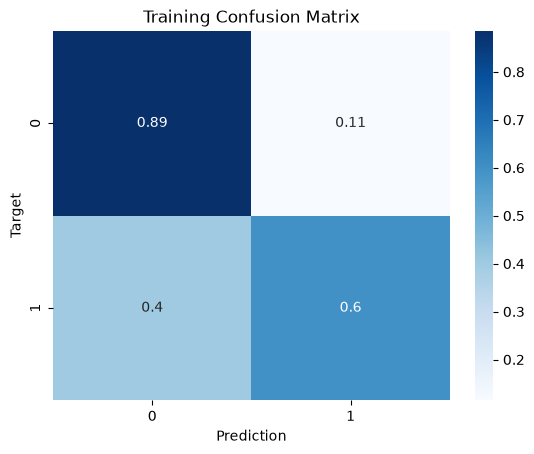

Accuracy: 85.77%
Area under ROC score on Validation dataset: 0.7922
f1_score: 0.4961


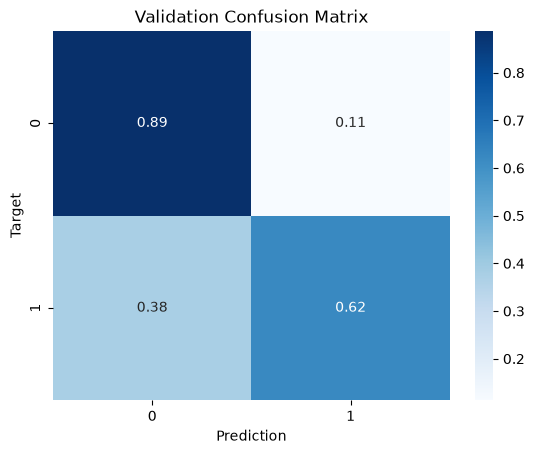

In [261]:
# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, name='Training')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, name='Validation')

# XGBClassifier

In [337]:
df_xgb = raw_df.drop(columns = ['duration'])

In [338]:
df_xgb['y'] = df_xgb['y'].map({'yes': 1, 'no': 0})

In [339]:
train_df, val_df = train_test_split(df_xgb, test_size=0.2, random_state=42, stratify = df_xgb['y'])

In [340]:
# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[0:-1]
target_col = 'y'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets =  val_df[input_cols].copy(), val_df[target_col].copy()

In [341]:
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [342]:
cat_features = train_inputs.select_dtypes(include='object').columns
train_inputs[categorical_cols] = train_inputs[categorical_cols].astype('category')
val_inputs[categorical_cols] = val_inputs[categorical_cols].astype('category')

In [343]:
val_inputs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8238 entries, 14455 to 33395
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             8238 non-null   int64   
 1   job             8238 non-null   category
 2   marital         8238 non-null   category
 3   education       8238 non-null   category
 4   default         8238 non-null   category
 5   housing         8238 non-null   category
 6   loan            8238 non-null   category
 7   contact         8238 non-null   category
 8   month           8238 non-null   category
 9   day_of_week     8238 non-null   category
 10  campaign        8238 non-null   int64   
 11  pdays           8238 non-null   int64   
 12  previous        8238 non-null   int64   
 13  poutcome        8238 non-null   category
 14  emp.var.rate    8238 non-null   float64 
 15  cons.price.idx  8238 non-null   float64 
 16  cons.conf.idx   8238 non-null   float64 
 17  euribor3m     

In [344]:
rus = RandomUnderSampler(random_state=42)
train_inputs, train_targets = rus.fit_resample(train_inputs, train_targets) 

In [345]:
xgb_clf = XGBClassifier(
    max_depth=3,
    n_estimators=10,
    enable_categorical=True,  # для категорійних ознак
    use_label_encoder=False,  # щоб уникнути попереджень, якщо використовуєте нові версії XGBoost
    missing=np.nan,  # явне вказування пропущених значень
    device='cuda'
)

xgb_clf.fit(train_inputs, train_targets)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


Accuracy: 74.41%
Area under ROC score on Training dataset: 0.8013
f1_score: 0.7097


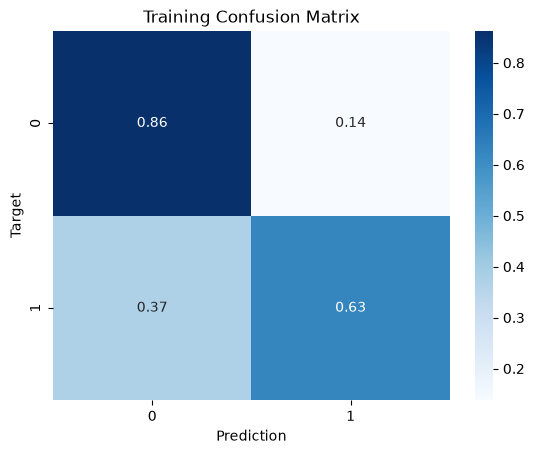

Accuracy: 83.82%
Area under ROC score on Validation dataset: 0.8050
f1_score: 0.4754


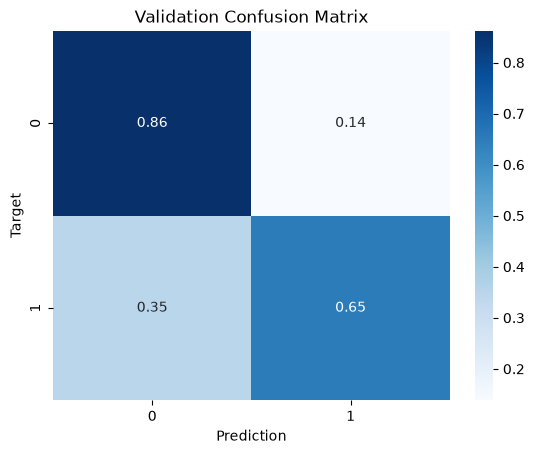

In [346]:
# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(xgb_clf, train_inputs, train_targets, name='Training')
val_preds = predict_and_plot(xgb_clf, val_inputs, val_targets, name='Validation')

# RandomizedSearchCV

In [347]:
params_dt = {
    'n_estimators': randint(50, 500),
    'learning_rate': uniform(0.01, 0.3),
    'max_depth': randint(3,16),
    'min_child_weight': randint(1,16),
    'subsample': uniform(0.5, 1.0),
    'colsample_bytree': uniform(0.5, 1.0),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1)
}

In [348]:
warnings.filterwarnings('ignore')
model =  xgb.XGBClassifier(random_state=42, eval_metric='auc',use_label_encoder=False,n_jobs=-1,verbosity=0)
xgb_random_search_best = RandomizedSearchCV(model, params_dt, n_iter=40, scoring='roc_auc', cv=3, random_state = 42)

xgb_random_search_best.fit(train_inputs, train_targets)

print(xgb_random_search_best.best_params_, xgb_random_search_best.best_score_)

{'colsample_bytree': np.float64(0.6834045098534338), 'gamma': np.float64(0.15212112147976886), 'learning_rate': np.float64(0.16742692948967136), 'max_depth': 14, 'min_child_weight': 9, 'n_estimators': 98, 'reg_alpha': np.float64(0.5247746602583891), 'reg_lambda': np.float64(0.3998609717152555), 'subsample': np.float64(0.5466656632136154)} 0.7687530935447903


Accuracy: 83.49%
Area under ROC score on Training dataset: 0.9225
f1_score: 0.8258


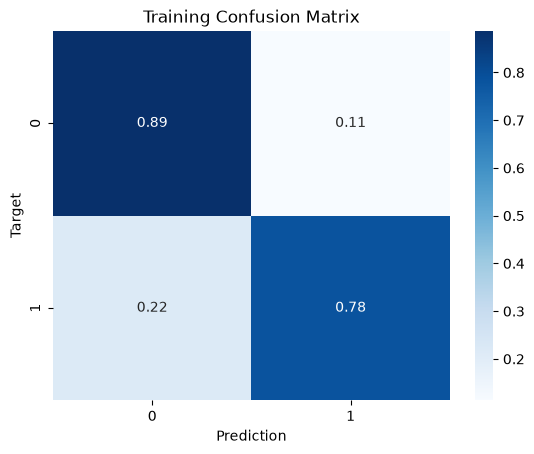

Accuracy: 77.73%
Area under ROC score on Validation dataset: 0.7902
f1_score: 0.4102


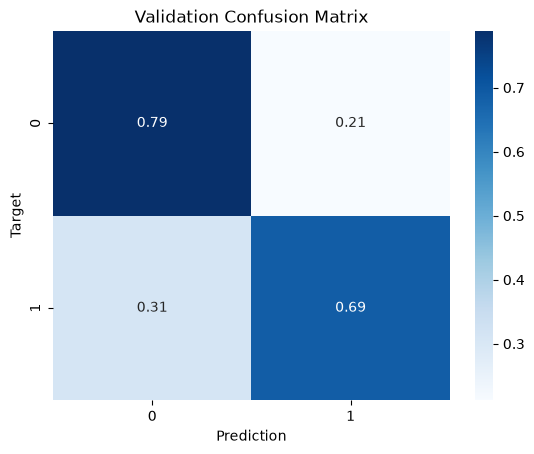

In [349]:
# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(xgb_random_search_best, train_inputs, train_targets, name='Training')
val_preds = predict_and_plot(xgb_random_search_best, val_inputs, val_targets, name='Validation')

# Hyperopt

In [350]:
def objective(params):
    clf = xgb.XGBClassifier(
    n_estimators=int(params['n_estimators']),
        learning_rate=params['learning_rate'],
        max_depth=int(params['max_depth']),
        min_child_weight=params['min_child_weight'],  # Мінімальна сума ваг всіх вибірок, необхідна в кінцевому вузлі
        subsample=params['subsample'],  # Частка вибірок, що використовуються для побудови кожного дерева
        colsample_bytree=params['colsample_bytree'],  # Частка ознак, що використовуються при побудові кожного дерева
        gamma=params['gamma'],  # Мінімальне зменшення втрат, необхідне для виконання поділу
        reg_alpha=params['reg_alpha'],  # Параметр регуляризації L1 (Lasso)
        reg_lambda=params['reg_lambda'],  # Параметр регуляризації L2 (Ridge)
        enable_categorical=True,
        use_label_encoder=False,
        missing=np.nan,
        device='cuda',
        early_stopping_rounds=10
    )

    clf.fit(
        train_inputs,
        train_targets,
        eval_set=[(val_inputs, val_targets)],
        verbose=False)
    pred = clf.predict_proba(val_inputs)[:,1]
    auc = roc_auc_score(val_targets, pred)

    return {'loss': -auc, 'status': STATUS_OK}

# Простір гіперпараметрів
space = {
    'n_estimators': hp.quniform('n_estimators', 50, 500, 25),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.3),
    'max_depth': hp.quniform('max_depth', 3, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 10, 1),
    'subsample': hp.uniform('subsample', 0.5, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 1)
}

# Оптимізація
trials = Trials()
best = fmin(fn=objective, space=space, algo=tpe.suggest, max_evals=20, trials=trials,verbose=False)

# Перетворення значень гіперпараметрів у кінцеві типи
best['n_estimators'] = int(best['n_estimators'])
best['max_depth'] = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Найкращі гіперпараметри: ", best)

# Навчання фінальної моделі з найкращими гіперпараметрами
final_clf = xgb.XGBClassifier(
    n_estimators=best['n_estimators'],
    learning_rate=best['learning_rate'],
    max_depth=best['max_depth'],
    min_child_weight=best['min_child_weight'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    gamma=best['gamma'],
    reg_alpha=best['reg_alpha'],
    reg_lambda=best['reg_lambda'],
    enable_categorical=True,
    use_label_encoder=False,
    missing=np.nan,
    device='cpu',
)

final_clf.fit(train_inputs, train_targets)
final_pred = final_clf.predict_proba(val_inputs)[:,1]
final_roc_auc_score = roc_auc_score(val_targets, final_pred)
print("Roc_auc_score на валідаційній вибірці: {:.4f}".format(final_roc_auc_score))

Найкращі гіперпараметри:  {'colsample_bytree': np.float64(0.9917183826509484), 'gamma': np.float64(0.2465379953203382), 'learning_rate': np.float64(0.18992458158801534), 'max_depth': 4, 'min_child_weight': 8, 'n_estimators': 50, 'reg_alpha': np.float64(0.6946866307894378), 'reg_lambda': np.float64(0.9689823160661044), 'subsample': np.float64(0.8383771745292561)}
Roc_auc_score на валідаційній вибірці: 0.8114


Accuracy: 75.46%
Area under ROC score on Training dataset: 0.8382
f1_score: 0.7226


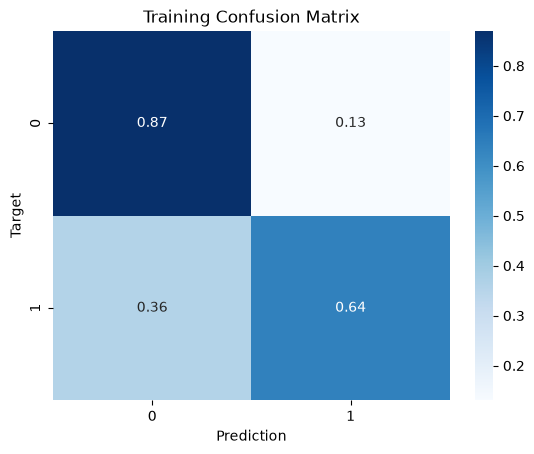

Accuracy: 83.77%
Area under ROC score on Validation dataset: 0.8114
f1_score: 0.4779


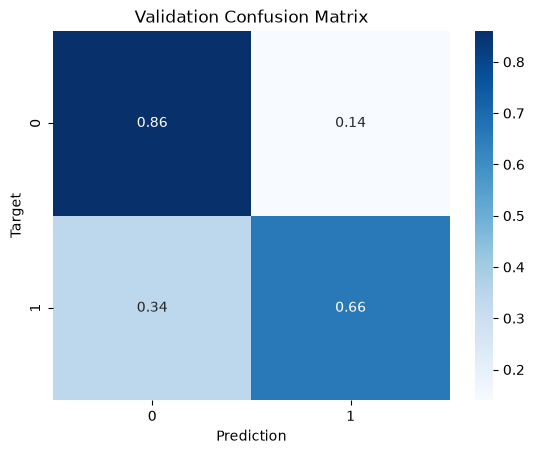

In [351]:
# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(final_clf, train_inputs, train_targets, name='Training')
val_preds = predict_and_plot(final_clf, val_inputs, val_targets, name='Validation')

Найклащою моделлю було обрано final_clf - XGBClassifier з підбором гіперпараметрів через Hyperopt.

# SHAP

In [354]:
# створюємо обʼєкт для пояснення прогнозів моделі за допомогою SHAP
explainer = shap.TreeExplainer(final_clf)
shap_values = explainer.shap_values(val_inputs)

# візуалізуємо пояснення першого прогнозу
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values[0,:], val_inputs.iloc[0,:])

На графіку бачимо які ознаки збільшують та зменшують вирогідність першого прогнозу. 

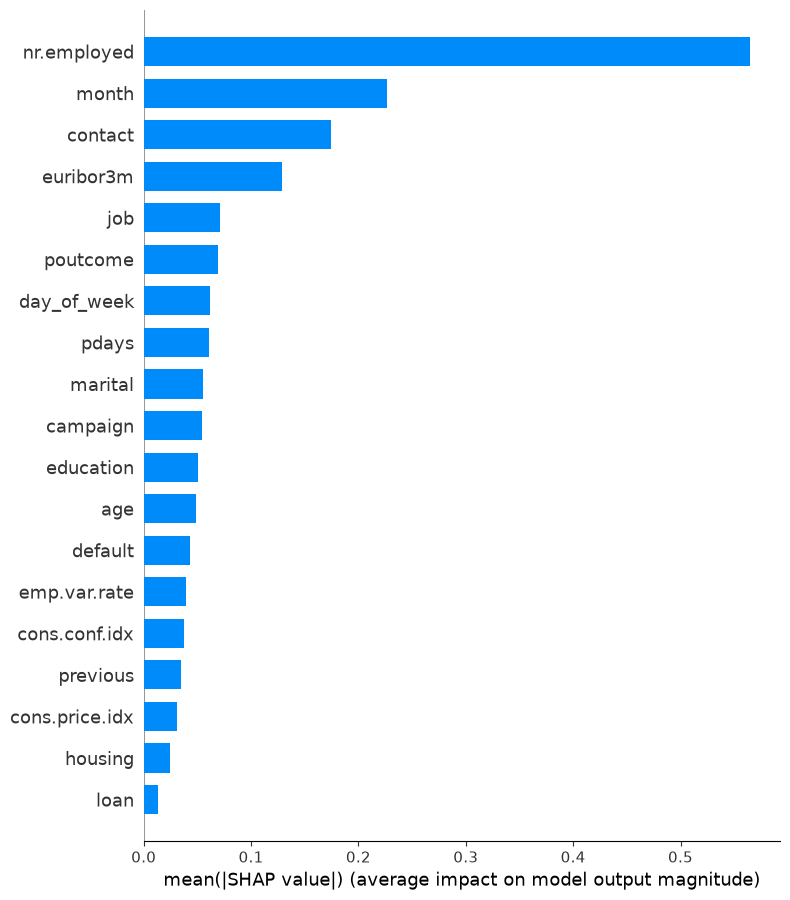

In [357]:
shap_values = shap.TreeExplainer(final_clf).shap_values(val_inputs)  # Обчислення значень SHAP
shap.summary_plot(shap_values, val_inputs, plot_type="bar")  # Побудова підсумкового графіка SHAP

На цьому графіку бачимо найважливіші ознаки, які впливають на рішення моделі. Порядок ознак виглядає логічним.

# Аналіз помилок

In [360]:
y_pred = final_clf.predict(val_inputs)

In [362]:
fp_mask = (val_targets == 0) & (y_pred == 1)
fn_mask = (val_targets == 1) & (y_pred == 0)

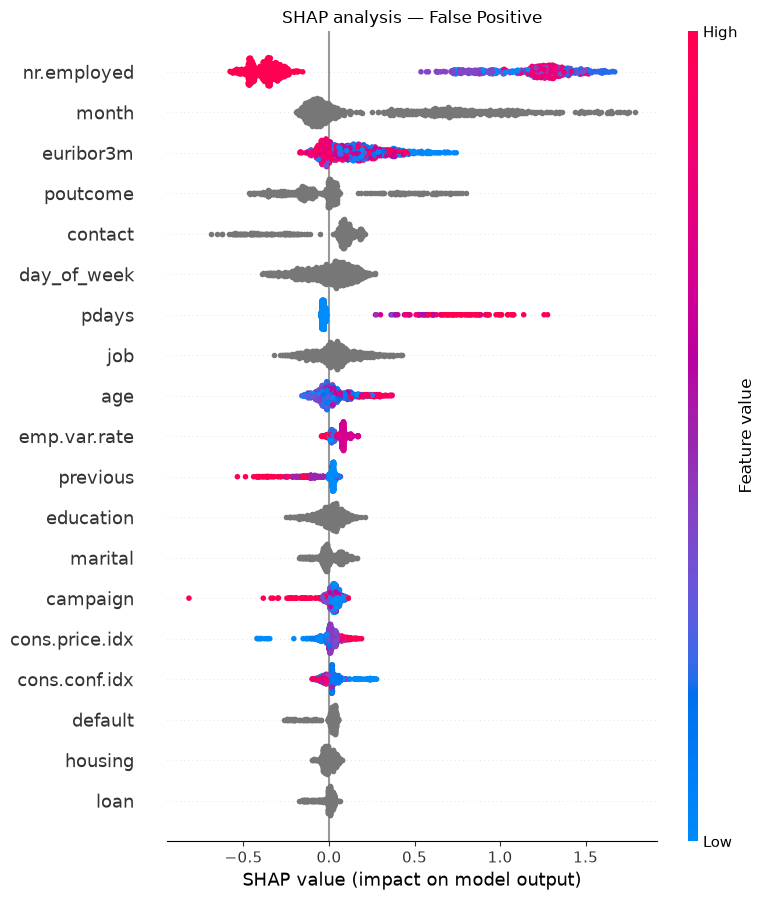

In [364]:
# False positive
shap.summary_plot(
    shap_values[fp_mask],
    val_inputs.loc[fp_mask],
    show=False
)

plt.title("SHAP analysis — False Positive")
plt.tight_layout()
plt.show()

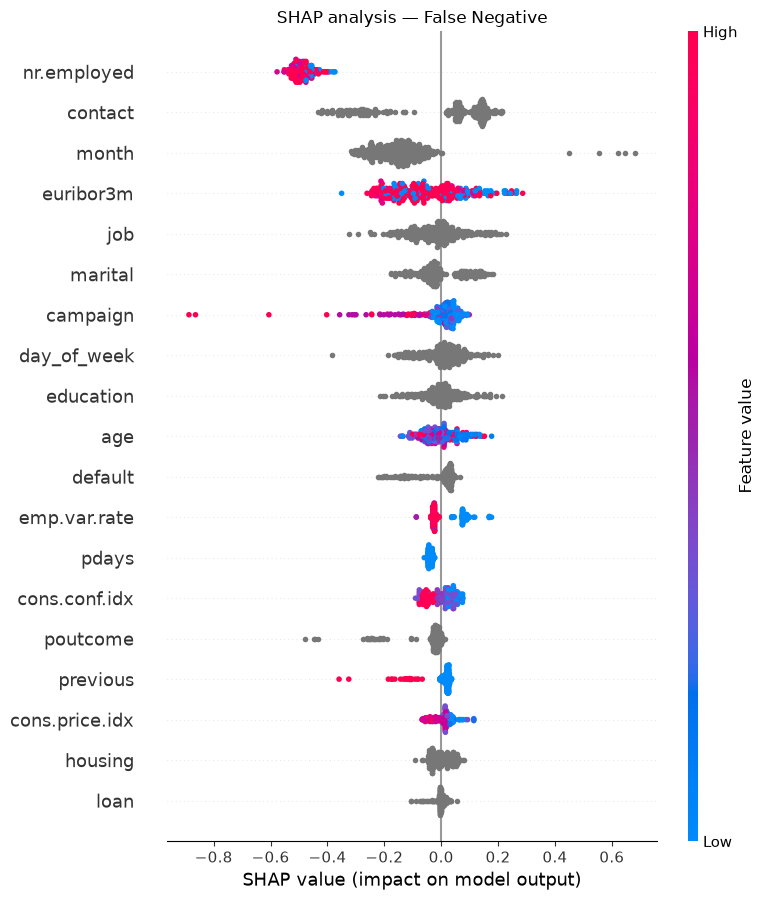

In [366]:
# False negative
shap.summary_plot(
    shap_values[fn_mask],
    val_inputs.loc[fn_mask],
    show=False
)

plt.title("SHAP analysis — False Negative")
plt.tight_layout()
plt.show()

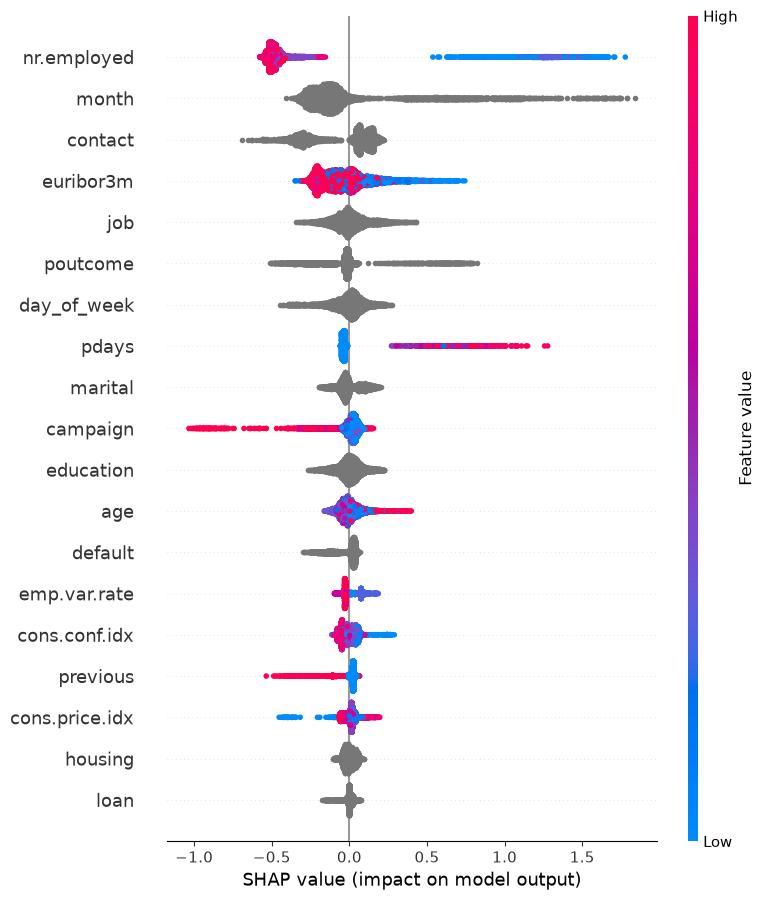

In [367]:
shap.summary_plot(
    shap_values,
    val_inputs
)

In [375]:
feature_names_shap = val_inputs.columns.tolist()
fp_importance = (
    np.abs(shap_values[fp_mask])
    .mean(axis=0)
)

fn_importance = (
    np.abs(shap_values[fn_mask])
    .mean(axis=0)
)

error_importance = pd.DataFrame({
    "feature": feature_names_shap,
    "FP_importance": fp_importance,
    "FN_importance": fn_importance
})

error_importance["total"] = (
    error_importance["FP_importance"] +
    error_importance["FN_importance"]
)

error_importance.sort_values(
    "total",
    ascending=False
).head(15)

,feature,FP_importance,FN_importance,total
18,nr.employed,0.80,0.49,1.28
8,month,0.42,0.16,0.59
7,contact,0.14,0.17,0.31
17,euribor3m,0.16,0.11,0.27
13,poutcome,0.15,0.04,0.19
9,day_of_week,0.11,0.05,0.16
1,job,0.09,0.07,0.16
11,pdays,0.10,0.04,0.14
0,age,0.07,0.05,0.11
2,marital,0.05,0.06,0.11


SHAP-аналіз показав, що найбільший вплив на помилки моделі має ознака nr.employed. Її середня важливість для False Positive становить 0.80, а для False Negative - 0.49, що суттєво перевищує вплив інших ознак.

Наступною за важливістю є ознака month (0.42 для FP та 0.16 для FN). Також помітний вплив мають contact, euribor3m, poutcome, day_of_week та job.

Для False Positive найбільший внесок мають nr.employed, month, contact, euribor3m та poutcome. Це означає, що саме ці ознаки найсильніше впливають на випадки, коли модель помилково відносить об'єкт до позитивного класу.

Для False Negative найбільш значущими є nr.employed, contact, month, euribor3m, job та campaign. Отже, помилки пропуску позитивного класу також значною мірою пов'язані з макроекономічними та характеристиками контакту з клієнтом.

Таким чином, помилки моделі не є рівномірно розподіленими між ознаками: основна частина впливу припадає на декілька найбільш важливих характеристик, насамперед nr.employed та month.

Оскільки nr.employed має значно більший SHAP-вплив порівняно з іншими ознаками, доцільно додатково перевірити стабільність моделі та залежність її результату від цієї ознаки, щоб переконатися, що модель не надмірно спирається на один фактор.

Для зменшення кількості помилок доцільно:
детальніше опрацювати ознаки nr.employed, month, contact та euribor3m, оскільки SHAP показав їх найбільший вплив на помилки. Можна перевірити їхні взаємодії та створити додаткові похідні ознаки.
Додати interaction features між найбільш важливими ознаками, якщо це має бізнесовий сенс.
Окремо оптимізувати модель під помилки False Positive та False Negative. 